# 04 — Evaluate Similarity: OD vs SD (Multi-Method, Multi-σ²)

Quantify how closely each synthesis method reproduces the original regression model across all (ρ, σ², rep) scenarios using:

1. **Euclidean distance** — $d(\hat{\beta}_{OD}, \hat{\beta}_{SD})$  
2. **Prediction drift** — MSE and MAE on an independent test set  
3. **Cosine similarity** — alignment of coefficient vectors  
4. **CI overlap %** — average confidence interval overlap across β₁…βₚ

Plot structure: **3×3 grids per method** (rows = ρ, columns = σ²).

In [14]:
# ── Imports ──────────────────────────────────────────────────────────────────
import json, os, glob, pickle, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.lines import Line2D

from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 200,
    "axes.titleweight": "bold", "axes.labelsize": 11,
    "font.family": "sans-serif",
})

In [15]:
# ── Load Configuration ──────────────────────────────────────────────────────
config_path = os.path.join("..", "config", "config.json")
with open(config_path) as f:
    config = json.load(f)

N_test       = config["simulation"]["N_test"]
p            = config["simulation"]["p"]
M            = config["simulation"]["M"]
test_seed    = config["simulation"]["test_seed"]
rho_vals     = config["parameters"]["rho"]
sigma_2_vals = config["parameters"]["sigma_2"]
beta         = np.array(config["parameters"]["beta"])
methods      = config["synthesis"]["methods"]

print(f"Test-set: N_test={N_test}, p={p}, seed={test_seed}")
print(f"Grid: {len(methods)} methods × {len(rho_vals)} ρ × {len(sigma_2_vals)} σ² × M={M}")
print(f"Methods: {methods}")

Test-set: N_test=10000, p=10, seed=123
Grid: 3 methods × 3 ρ × 3 σ² × M=100
Methods: ['cart', 'norm', 'pmm']


In [16]:
# ── Helper: generate independent test datasets ─────────────────────────────
def make_sigma(p, rho):
    Sigma = np.full((p, p), rho)
    np.fill_diagonal(Sigma, 1.0)
    return Sigma


def generate_test(N, p, rho, beta, sigma_2, seed):
    rng = np.random.default_rng(seed)
    Sigma = make_sigma(p, rho)
    X = rng.multivariate_normal(np.zeros(p), Sigma, size=N)
    X_design = np.column_stack([np.ones(N), X])
    epsilon = rng.normal(0, np.sqrt(sigma_2), size=N)
    y = X_design @ beta + epsilon
    df = pd.DataFrame(X, columns=[f"X{i+1}" for i in range(p)])
    df["y"] = y
    return df


# Pre-generate test sets for every (rho, sigma_2)
test_sets = {}
for rho in rho_vals:
    for sigma in sigma_2_vals:
        test_sets[(rho, sigma)] = generate_test(
            N_test, p, rho, beta, sigma, seed=test_seed
        )

print(f"Pre-generated {len(test_sets)} test sets.")

Pre-generated 9 test sets.


In [17]:
# ── Discover saved model files ─────────────────────────────────────────────
model_dir  = os.path.join("..", "models")
result_dir = os.path.join("..", "results")
os.makedirs(result_dir, exist_ok=True)

model_files = sorted(glob.glob(os.path.join(model_dir, "models_*.pkl")))
assert len(model_files) > 0, f"No model files found in {model_dir}"
print(f"Found {len(model_files)} model pair(s) to evaluate.")

Found 2700 model pair(s) to evaluate.


## Evaluate Each Scenario

In [18]:
# ── Evaluate all model pairs ───────────────────────────────────────────────
all_metrics = []

for i, mf in enumerate(model_files):
    with open(mf, "rb") as f:
        bundle = pickle.load(f)

    lm_od    = bundle["lm_od"]
    lm_sd    = bundle["lm_sd"]
    scenario = bundle["scenario"]
    method   = bundle.get("method", "cart")
    rho      = bundle.get("rho")
    sigma    = bundle.get("sigma_2")
    rep      = bundle.get("rep")

    # Fallback parsing
    if rho is None:
        rho = float(re.search(r"rho([\d.]+)", scenario).group(1))
    if sigma is None:
        m = re.search(r"sigma([\d.]+)", scenario)
        sigma = float(m.group(1)) if m else 1.0
    if rep is None:
        m = re.search(r"rep(\d+)", scenario)
        rep = int(m.group(1)) if m else 1

    # (a) Coefficient vectors
    beta_od = np.concatenate([[lm_od.intercept_], lm_od.coef_])
    beta_sd = np.concatenate([[lm_sd.intercept_], lm_sd.coef_])

    eucl_dist    = np.linalg.norm(beta_od - beta_sd)
    max_abs_diff = np.max(np.abs(beta_od - beta_sd))
    cos_sim      = np.dot(beta_od, beta_sd) / (np.linalg.norm(beta_od) * np.linalg.norm(beta_sd))

    # (b) Prediction-based metrics
    test_data = test_sets[(rho, sigma)]
    X_test = test_data.drop(columns="y")

    pred_od = lm_od.predict(X_test)
    pred_sd = lm_sd.predict(X_test)

    mse_pred  = mean_squared_error(pred_od, pred_sd)
    mae_pred  = mean_absolute_error(pred_od, pred_sd)
    pred_corr = np.corrcoef(pred_od, pred_sd)[0, 1]

    all_metrics.append({
        "scenario": scenario, "method": method,
        "rho": rho, "sigma_2": sigma, "rep": rep,
        "euclidean_dist": eucl_dist,
        "max_abs_coef_diff": max_abs_diff,
        "cosine_similarity": cos_sim,
        "prediction_mse": mse_pred,
        "prediction_mae": mae_pred,
        "prediction_corr": pred_corr,
    })

    if (i + 1) % 500 == 0 or i == len(model_files) - 1:
        print(f"  Evaluated {i + 1}/{len(model_files)}...")

metrics_df = pd.DataFrame(all_metrics)
print(f"\nDone. Metrics shape: {metrics_df.shape}")

/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearR

  Evaluated 500/2700...


/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearR

  Evaluated 1000/2700...


/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearR

...

/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearR

  Evaluated 2000/2700...


/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearR

  Evaluated 2500/2700...
  Evaluated 2700/2700...

Done. Metrics shape: (2700, 11)


/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearR

## Summary Tables

In [19]:
# ── Summary aggregated by (method, rho, sigma_2) ──────────────────────────
numeric_cols = ["euclidean_dist", "max_abs_coef_diff", "cosine_similarity",
                "prediction_mse", "prediction_mae", "prediction_corr"]

summary = (
    metrics_df
    .groupby(["method", "rho", "sigma_2"])[numeric_cols]
    .agg(["mean", "std"])
    .round(6)
)
display(summary)

# Save
out_path = os.path.join(result_dir, "evaluation_metrics.csv")
metrics_df.to_csv(out_path, index=False)
print(f"\nFull metrics saved to: {out_path}")

euclidean_dist           max_abs_coef_diff            \
                             mean       std              mean       std   
method rho sigma_2                                                        
cart   0.0 1.0           1.496384  0.106851          0.722407  0.082244   
           1.5           1.498684  0.126103          0.733402  0.090813   
           2.0           1.469530  0.132107          0.721370  0.091685   
       0.3 1.0           1.083122  0.162788          0.625328  0.108545   
           1.5           1.110464  0.179135          0.646873  0.122401   
           2.0           1.089828  0.172324          0.623099  0.120870   
       0.6 1.0           1.119196  0.226056          0.647741  0.150458   
           1.5           1.083993  0.212395          0.627432  0.144386   
           2.0           1.116383  0.232147          0.654071  0.150625   
norm   0.0 1.0           0.145800  0.033527          0.087515  0.022910   
           1.5           0.177211  0.042602          0.104426  0.028356   
           2.0           0.207242  0.045457          0.125674  0.035897   
       0.3 1.0           0.164832  0.039135          0.097106  0.027632   
           1.5           0.207200  0.045984          0.125477  0.036206   
           2.0           0.242454  0.054885          0.141574  0.038596   
       0.6 1.0           0.213943  0.049603          0.128210  0.035925   
           1.5           0.256550  0.059197          0.145549  0.037797   
           2.0           0.306771  0.067702          0.181233  0.044444   
pmm    0.0 1.0           0.146472  0.036018          0.085918  0.024391   
           1.5           0.176607  0.042302          0.105287  0.029307   
           2.0           0.221384  0.052568          0.134451  0.038887   
       0.3 1.0           0.165145  0.037689          0.093782  0.026519   
           1.5           0.202456  0.049603          0.125900  0.041162   
           2.0           0.231179  0.044201          0.133598  0.035874   
       0.6 1.0           0.221429  0.047492          0.131417  0.038625   
           1.5           0.264863  0.060462          0.159828  0.044865   
           2.0           0.298926  0.072153          0.180994  0.054841   

                   cosine_similarity           prediction_mse            \
                                mean       std           mean       std   
method rho sigma_2                                                        
cart   0.0 1.0              0.940078  0.017608       2.204809  0.312206   
           1.5              0.936928  0.021001       2.217017  0.371405   
           2.0              0.938751  0.019991       2.132246  0.376315   
       0.3 1.0              0.946656  0.019160       1.761441  0.432455   
           1.5              0.943042  0.020001       1.780354  0.444665   
           2.0              0.945028  0.019881       1.727970  0.436321   
       0.6 1.0              0.941286  0.022227       0.937607  0.281336   
           1.5              0.945131  0.019771       0.842820  0.268261   
           2.0              0.941953  0.022638       0.896327  0.301029   
norm   0.0 1.0              0.999074  0.000422       0.022383  0.009830   
           1.5              0.998656  0.000647       0.033171  0.015247   
           2.0              0.998122  0.000884       0.044942  0.019649   
       0.3 1.0              0.998732  0.000612       0.022492  0.010526   
           1.5              0.998013  0.000860       0.034957  0.014761   
           2.0              0.997254  0.001224       0.048043  0.019624   
       0.6 1.0              0.997842  0.000990       0.022772  0.009135   
           1.5              0.996923  0.001416       0.032951  0.013922   
           2.0              0.995628  0.001917       0.046914  0.020075   
pmm    0.0 1.0              0.999068  0.000480       0.022757  0.010878   
           1.5              0.998651  0.000681       0.032954  0.015411   
           2.0              0.997906  0.001


Full metrics saved to: ../results/evaluation_metrics.csv


## Visualisations — Per-Method 3×3 Grids

For each synthesis method, a **3×3 grid** where rows = ρ and columns = σ².

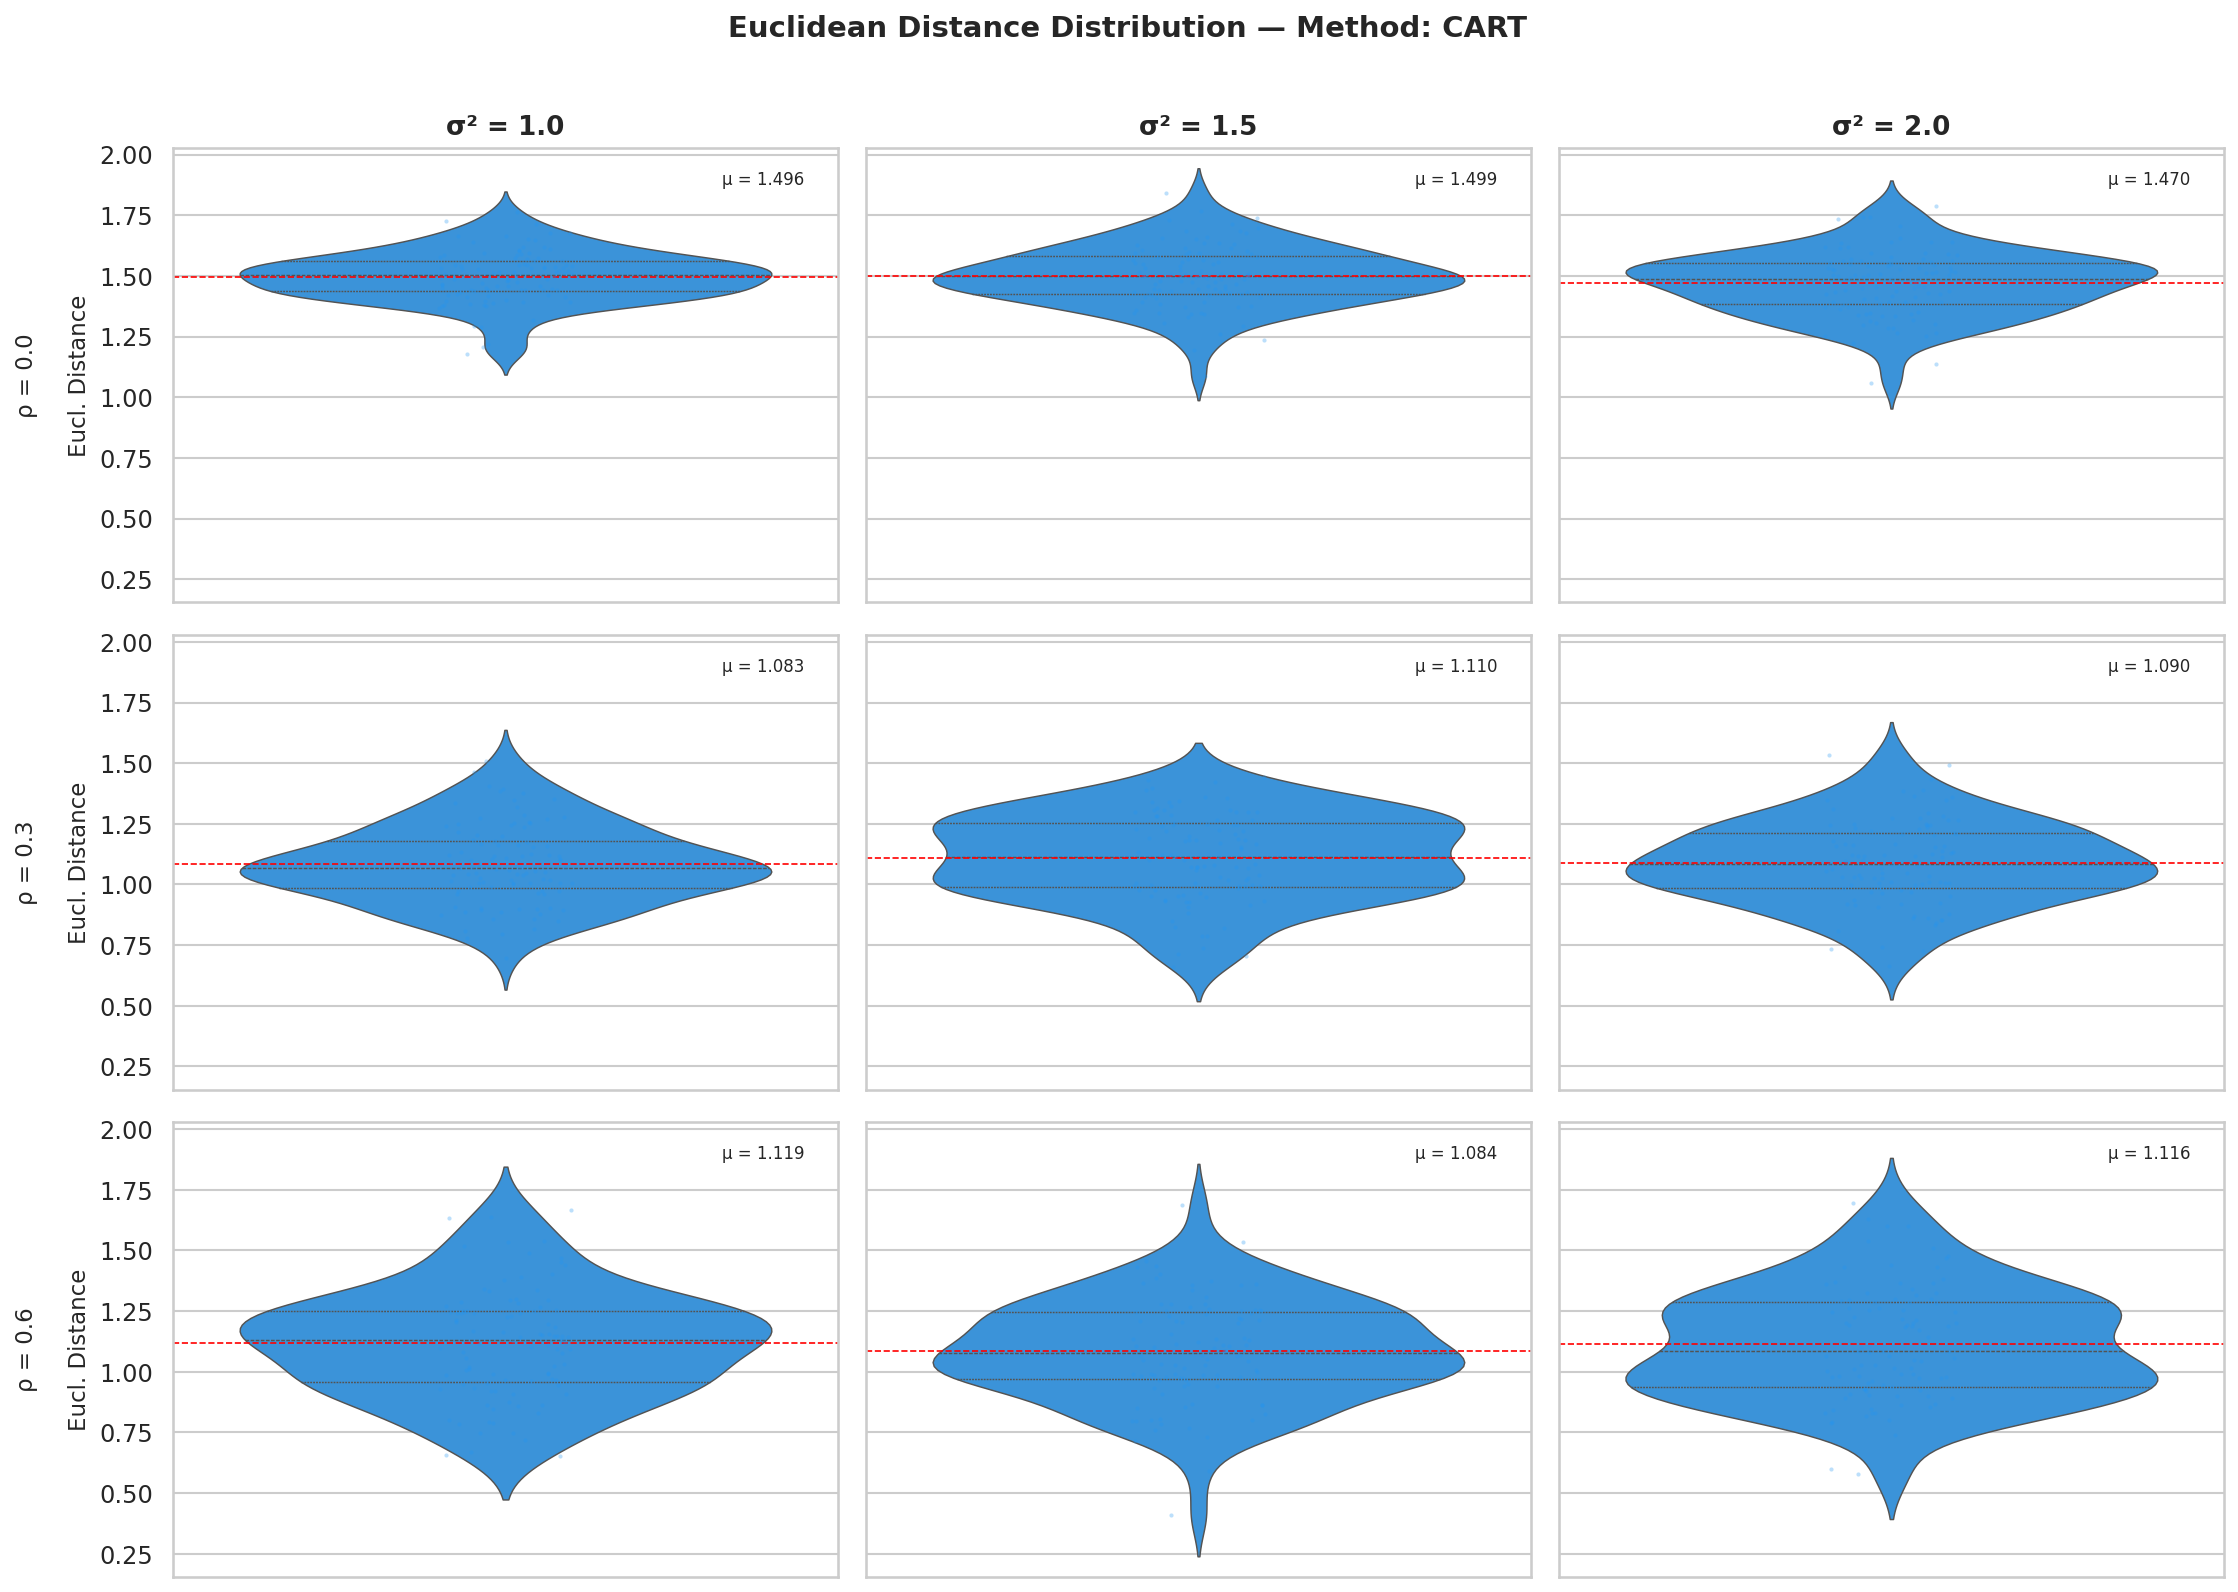

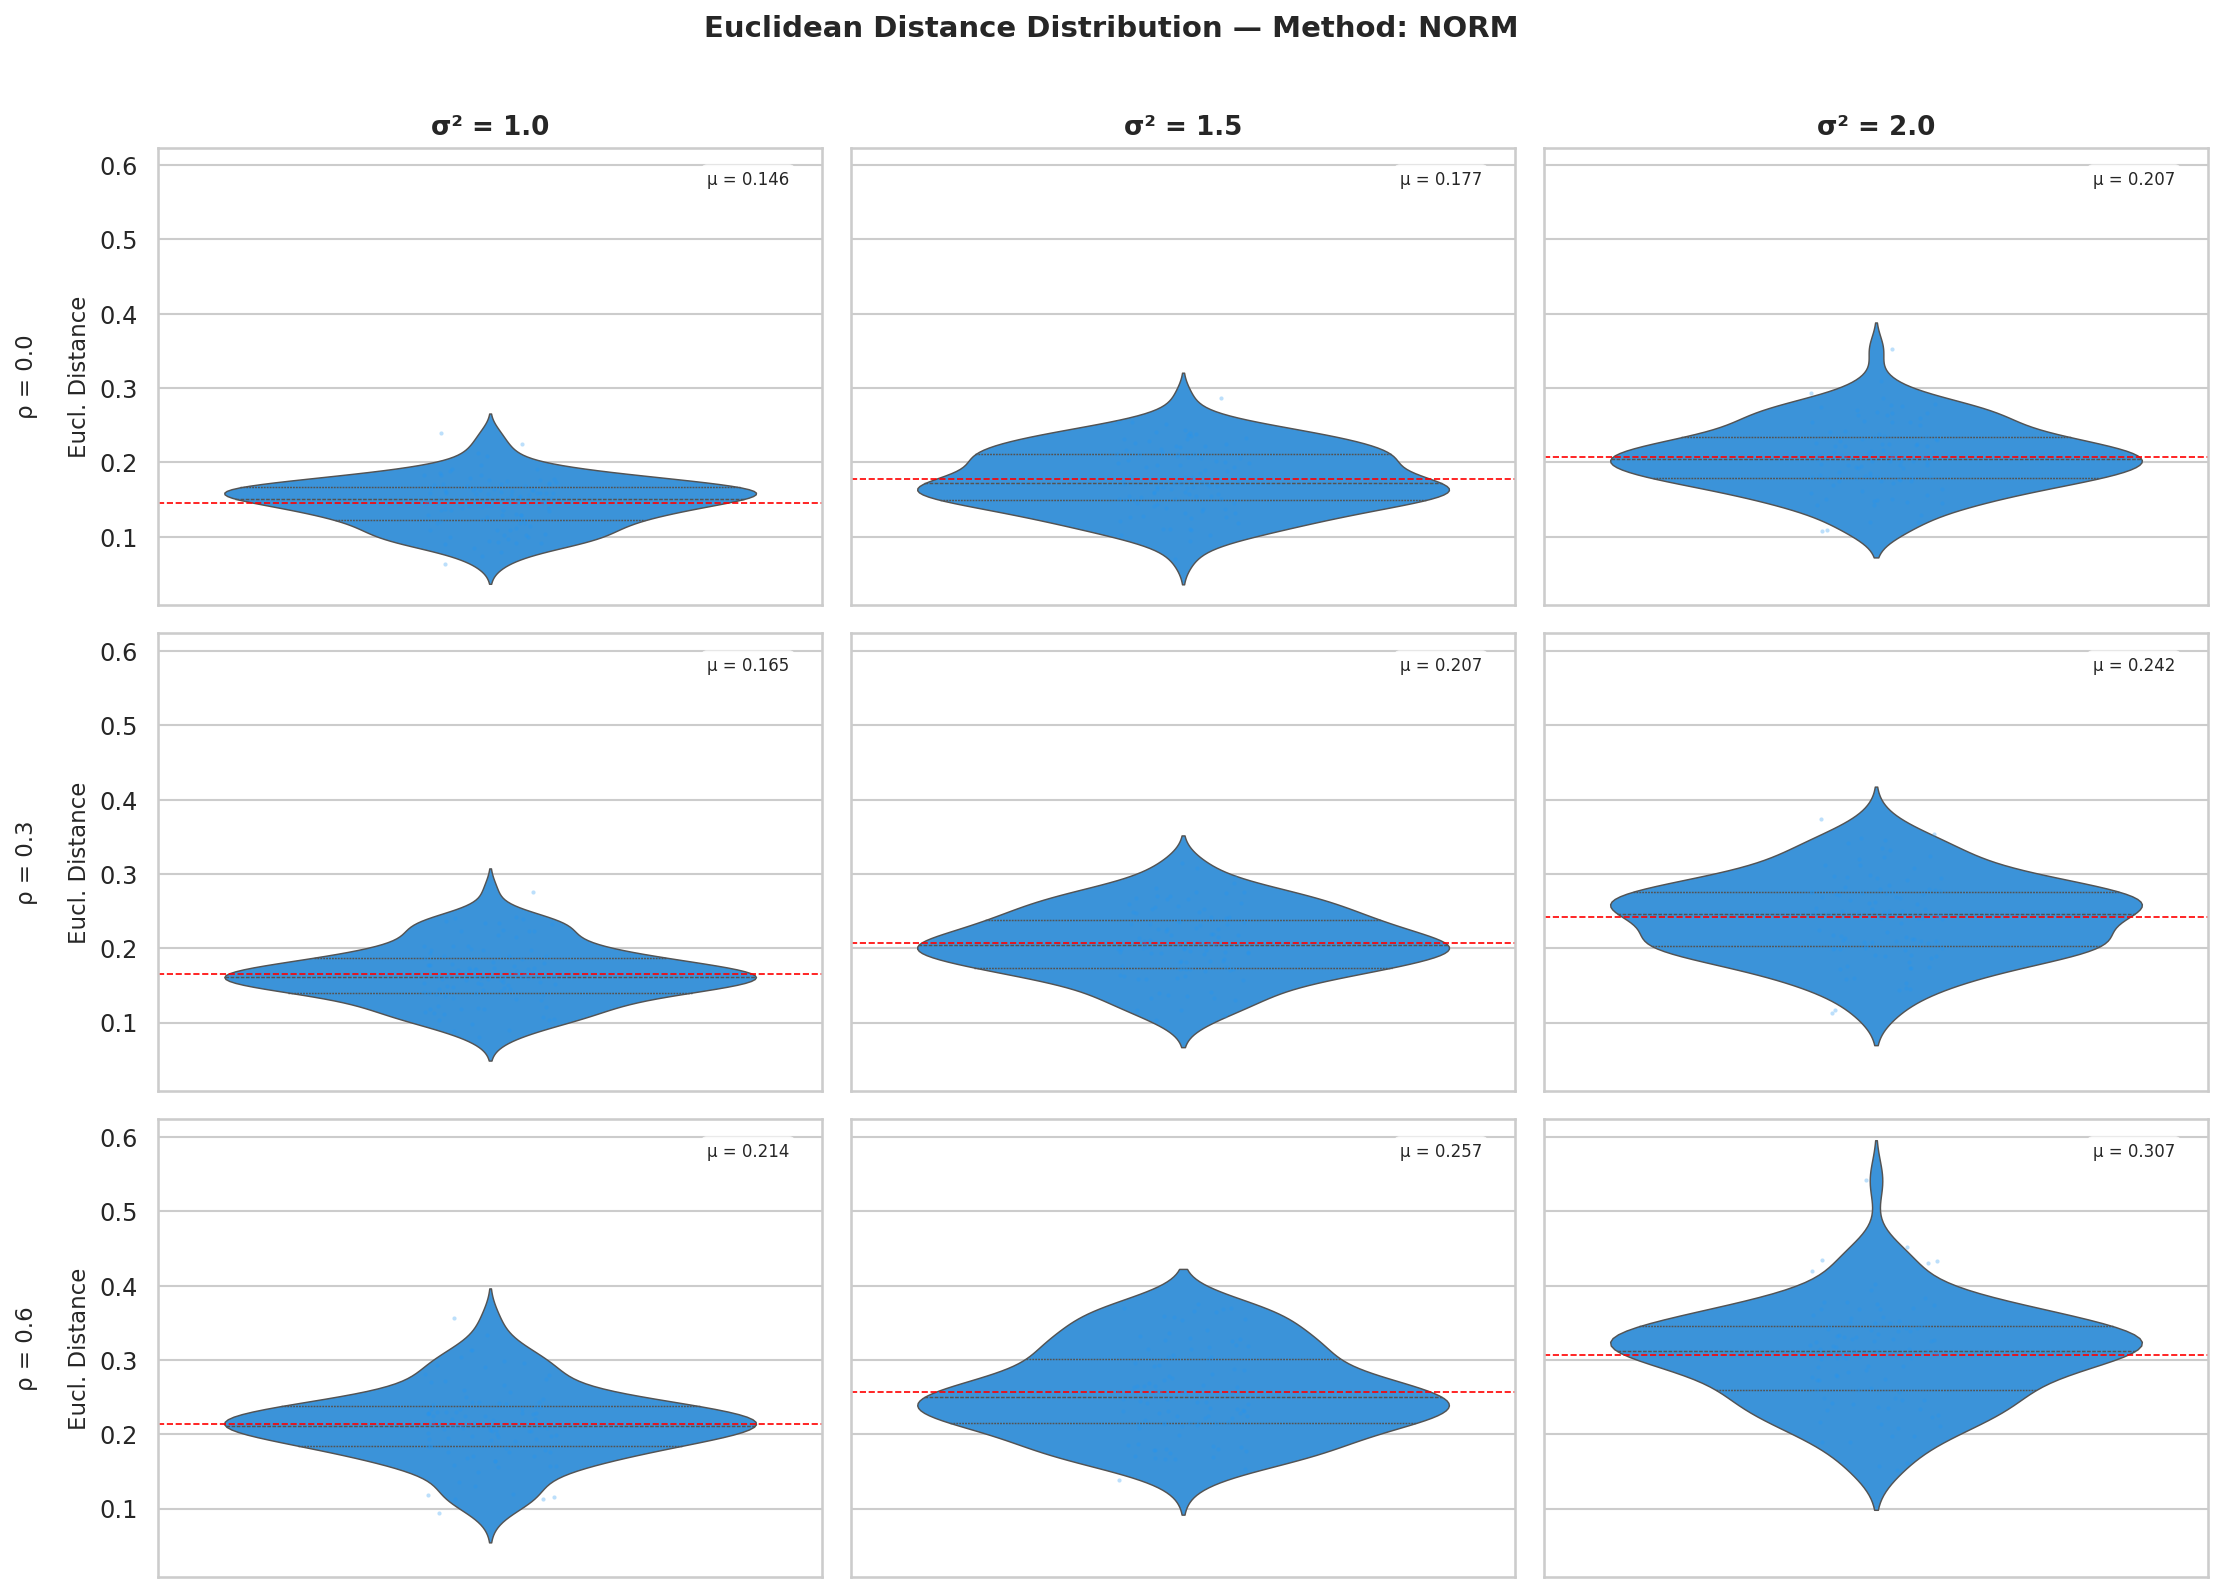

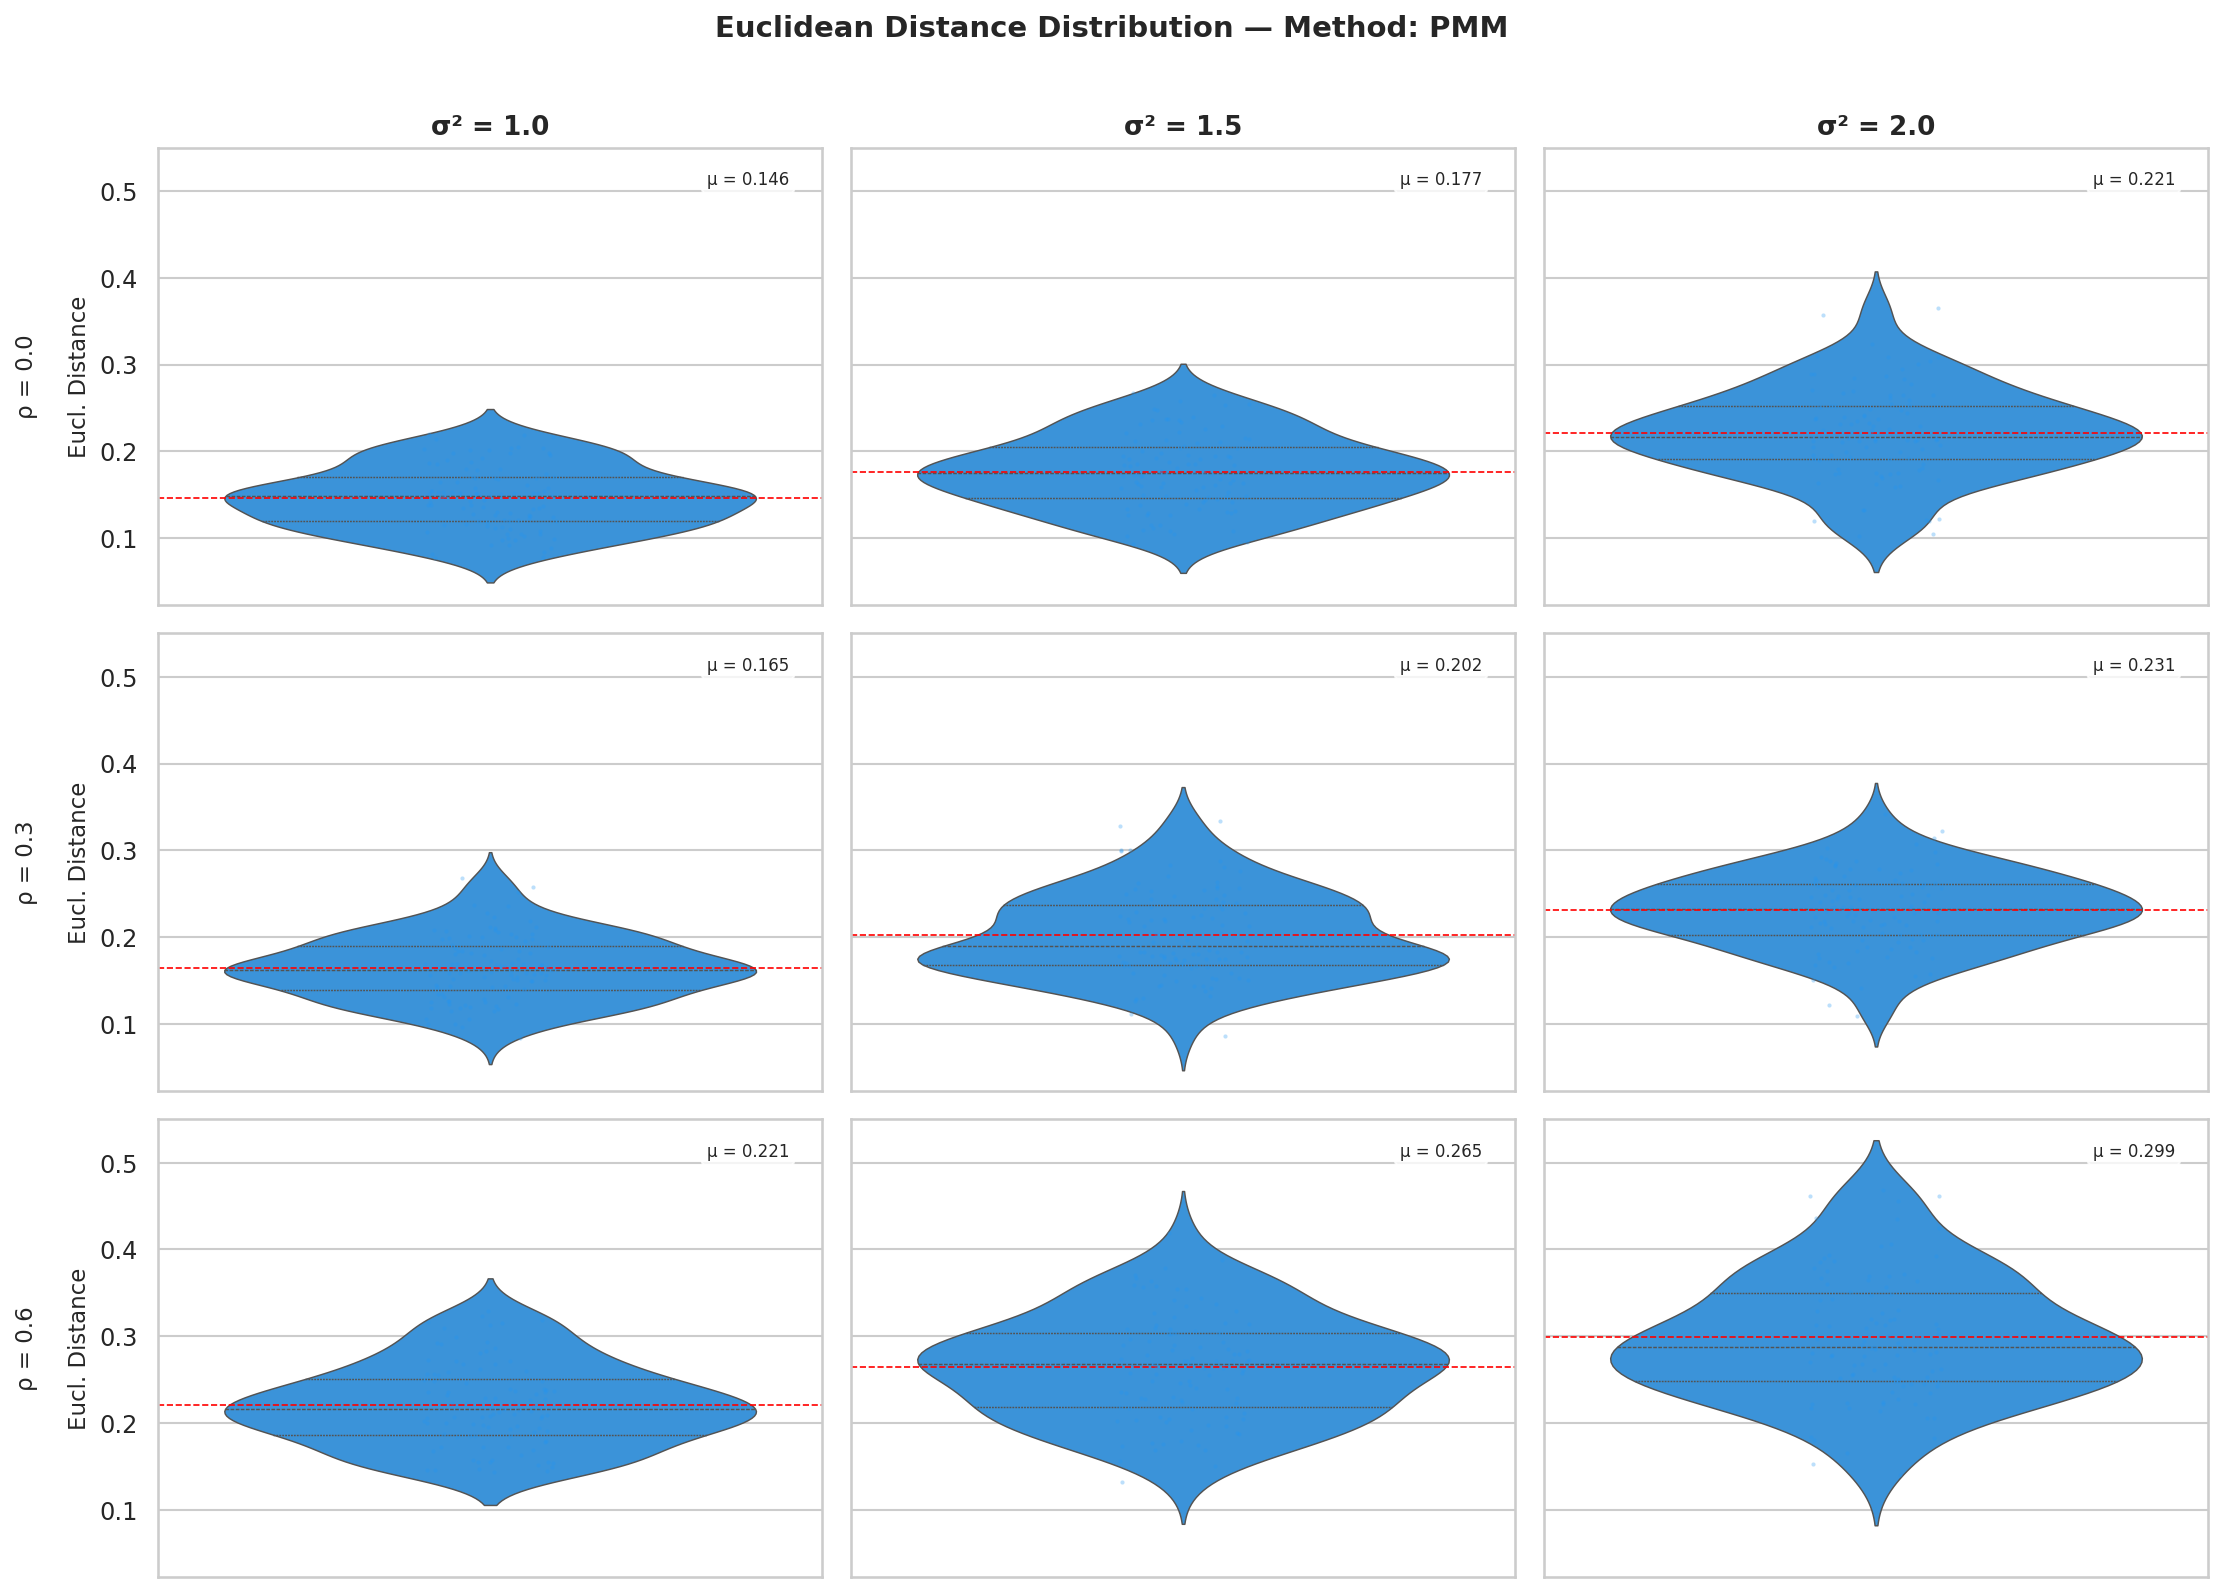

In [20]:
# ── Plot Set A: Euclidean Distance Violin — per method, 3×3 grid ──────────
rho_sorted   = sorted(metrics_df["rho"].unique())
sigma_sorted = sorted(metrics_df["sigma_2"].unique())

for method in methods:
    fig, axes = plt.subplots(
        len(rho_sorted), len(sigma_sorted),
        figsize=(5 * len(sigma_sorted), 3.5 * len(rho_sorted)),
        sharex=False, sharey=True,
    )

    for ri, rho in enumerate(rho_sorted):
        for si, sigma in enumerate(sigma_sorted):
            ax = axes[ri, si]
            sub = metrics_df[
                (metrics_df["method"] == method) &
                (metrics_df["rho"] == rho) &
                (metrics_df["sigma_2"] == sigma)
            ]

            if len(sub) == 0:
                ax.set_visible(False)
                continue

            sns.violinplot(
                data=sub, y="euclidean_dist",
                color="#2196F3", inner="quart", ax=ax, linewidth=0.7,
            )
            sns.stripplot(
                data=sub, y="euclidean_dist",
                color="#2196F3", alpha=0.3, size=2, ax=ax, jitter=True,
            )

            mean_val = sub["euclidean_dist"].mean()
            ax.axhline(mean_val, color="red", ls="--", lw=0.8)
            ax.text(0.95, 0.95, f"μ = {mean_val:.3f}",
                    transform=ax.transAxes, ha="right", va="top", fontsize=8,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

            if ri == 0:
                ax.set_title(f"σ² = {sigma}")
            if si == 0:
                ax.set_ylabel(f"ρ = {rho}\n\nEucl. Distance")
            else:
                ax.set_ylabel("")
            ax.set_xlabel("")

    fig.suptitle(f"Euclidean Distance Distribution — Method: {method.upper()}",
                 fontweight="bold", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"plot_eucl_dist_grid_{method}.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearR

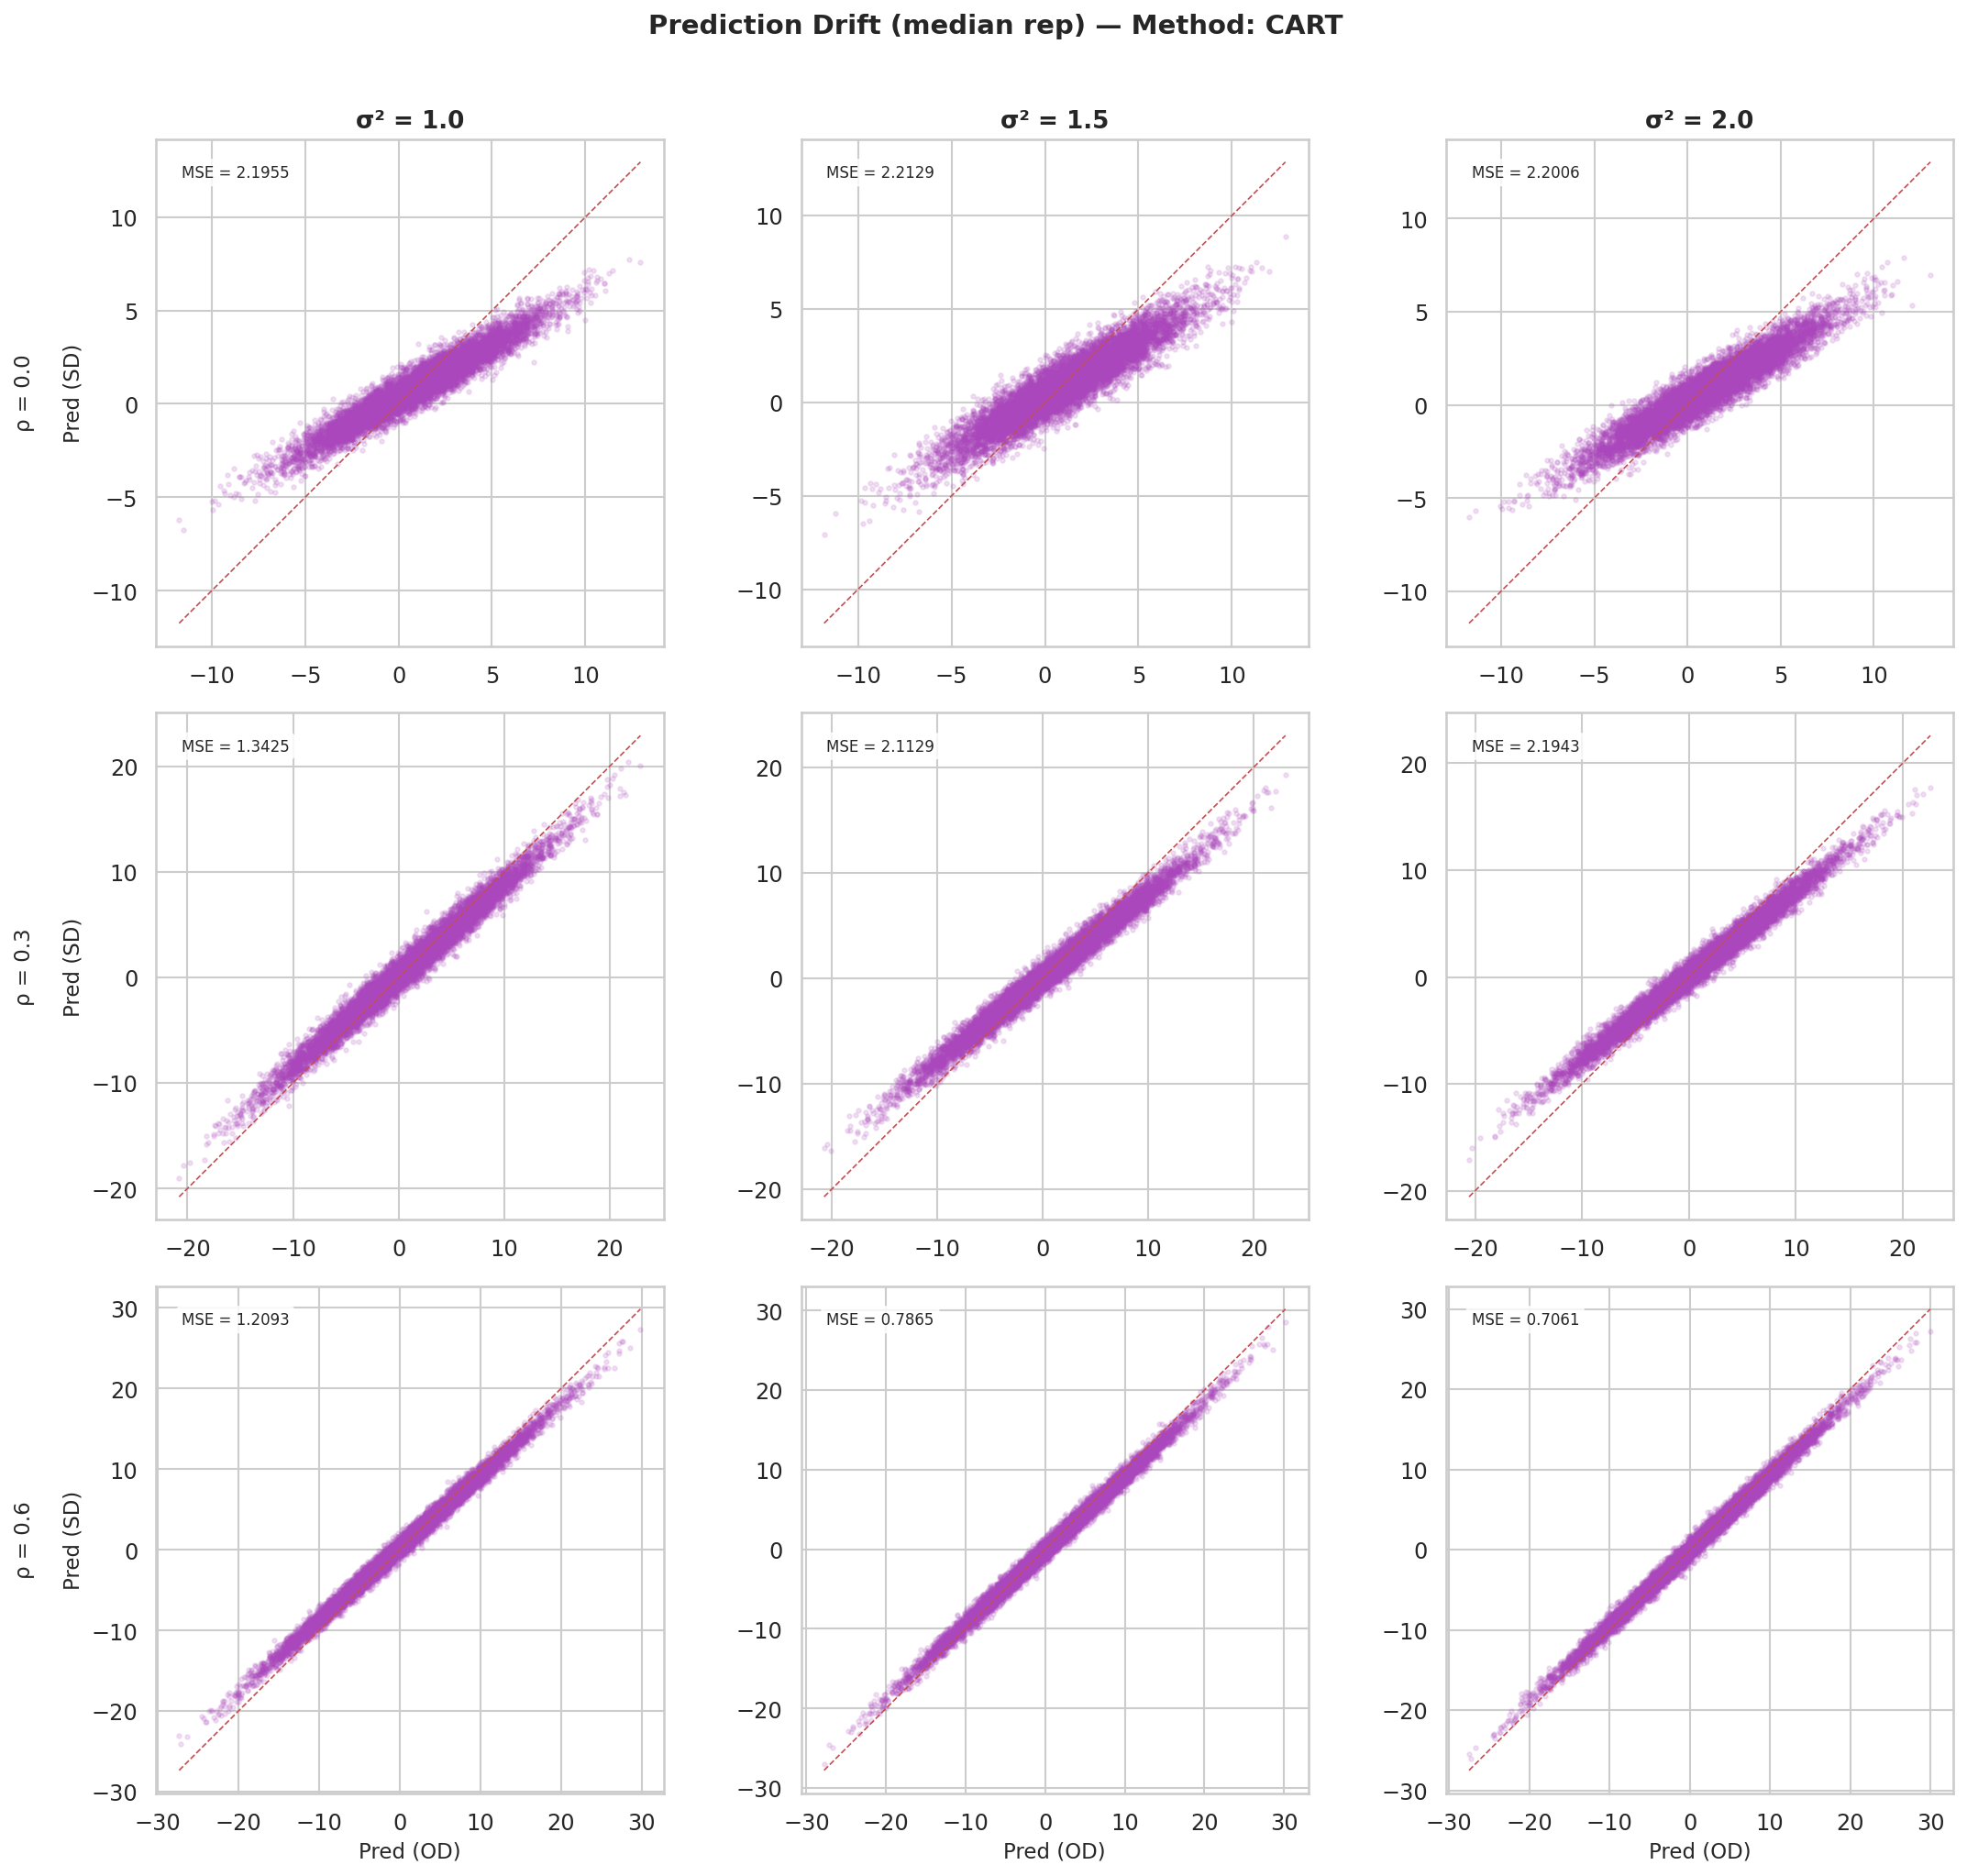

/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearR

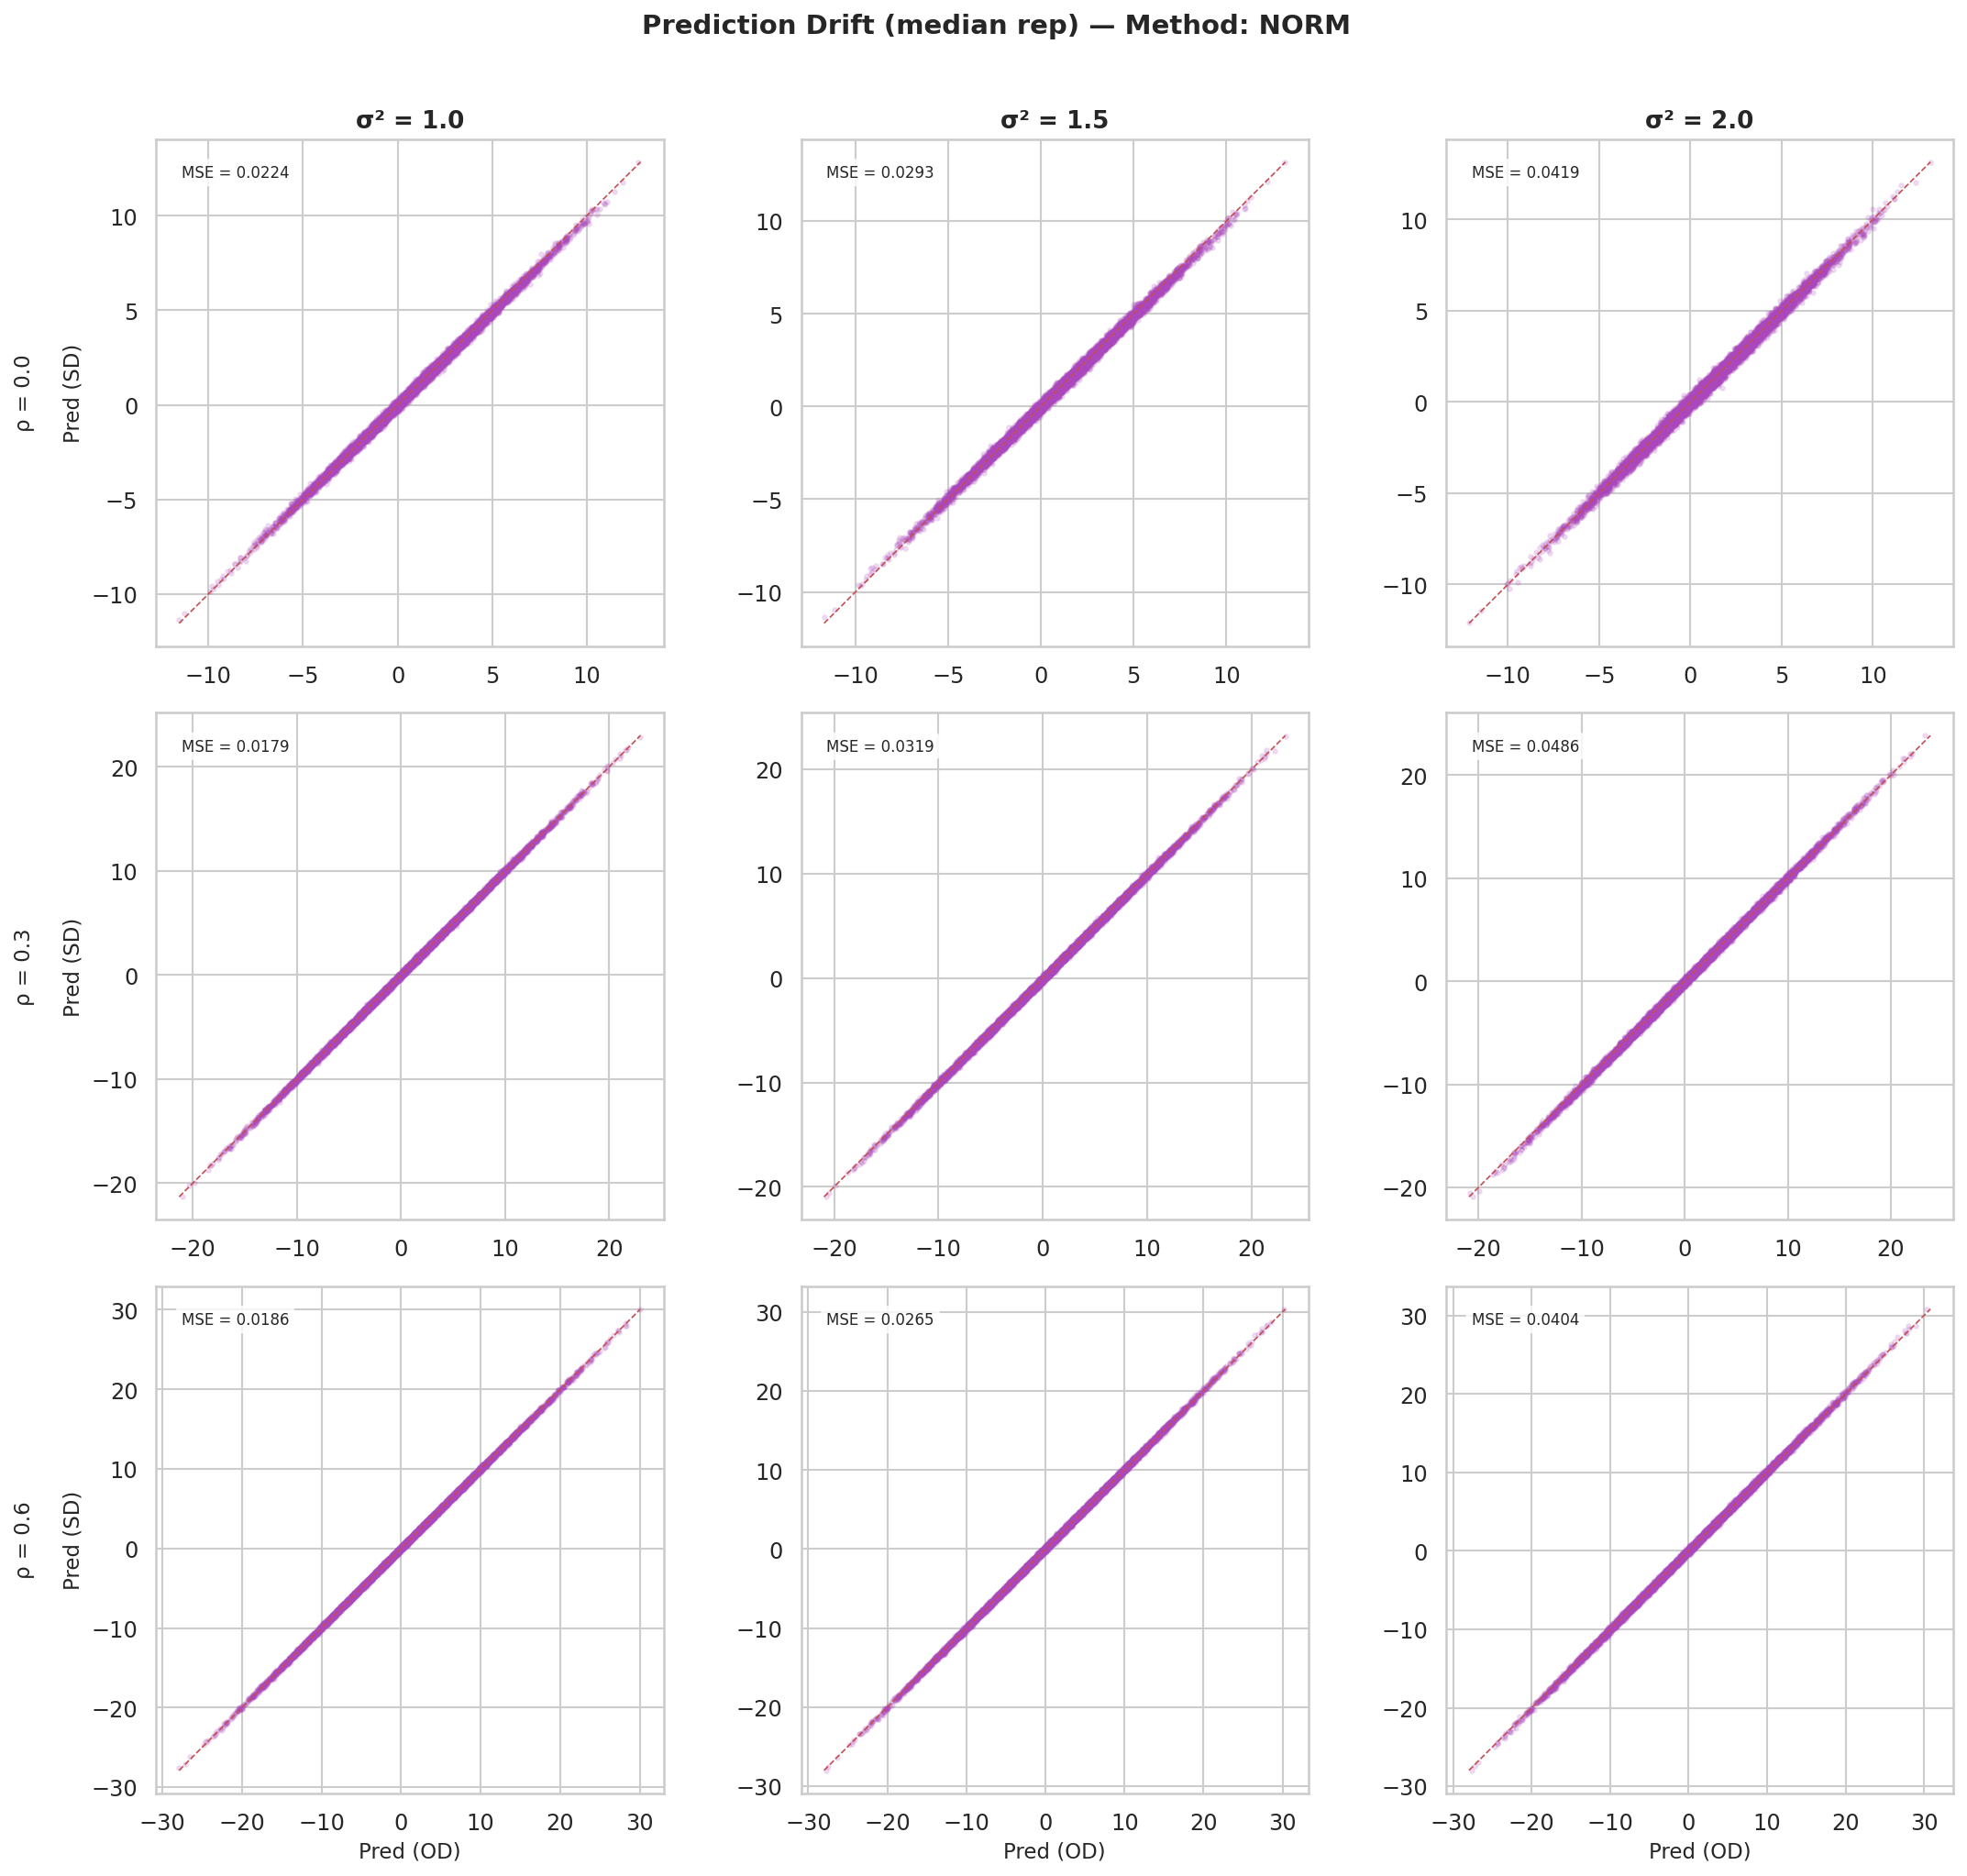

/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/home/sterry/miniconda3/envs/synthetic_data/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearR

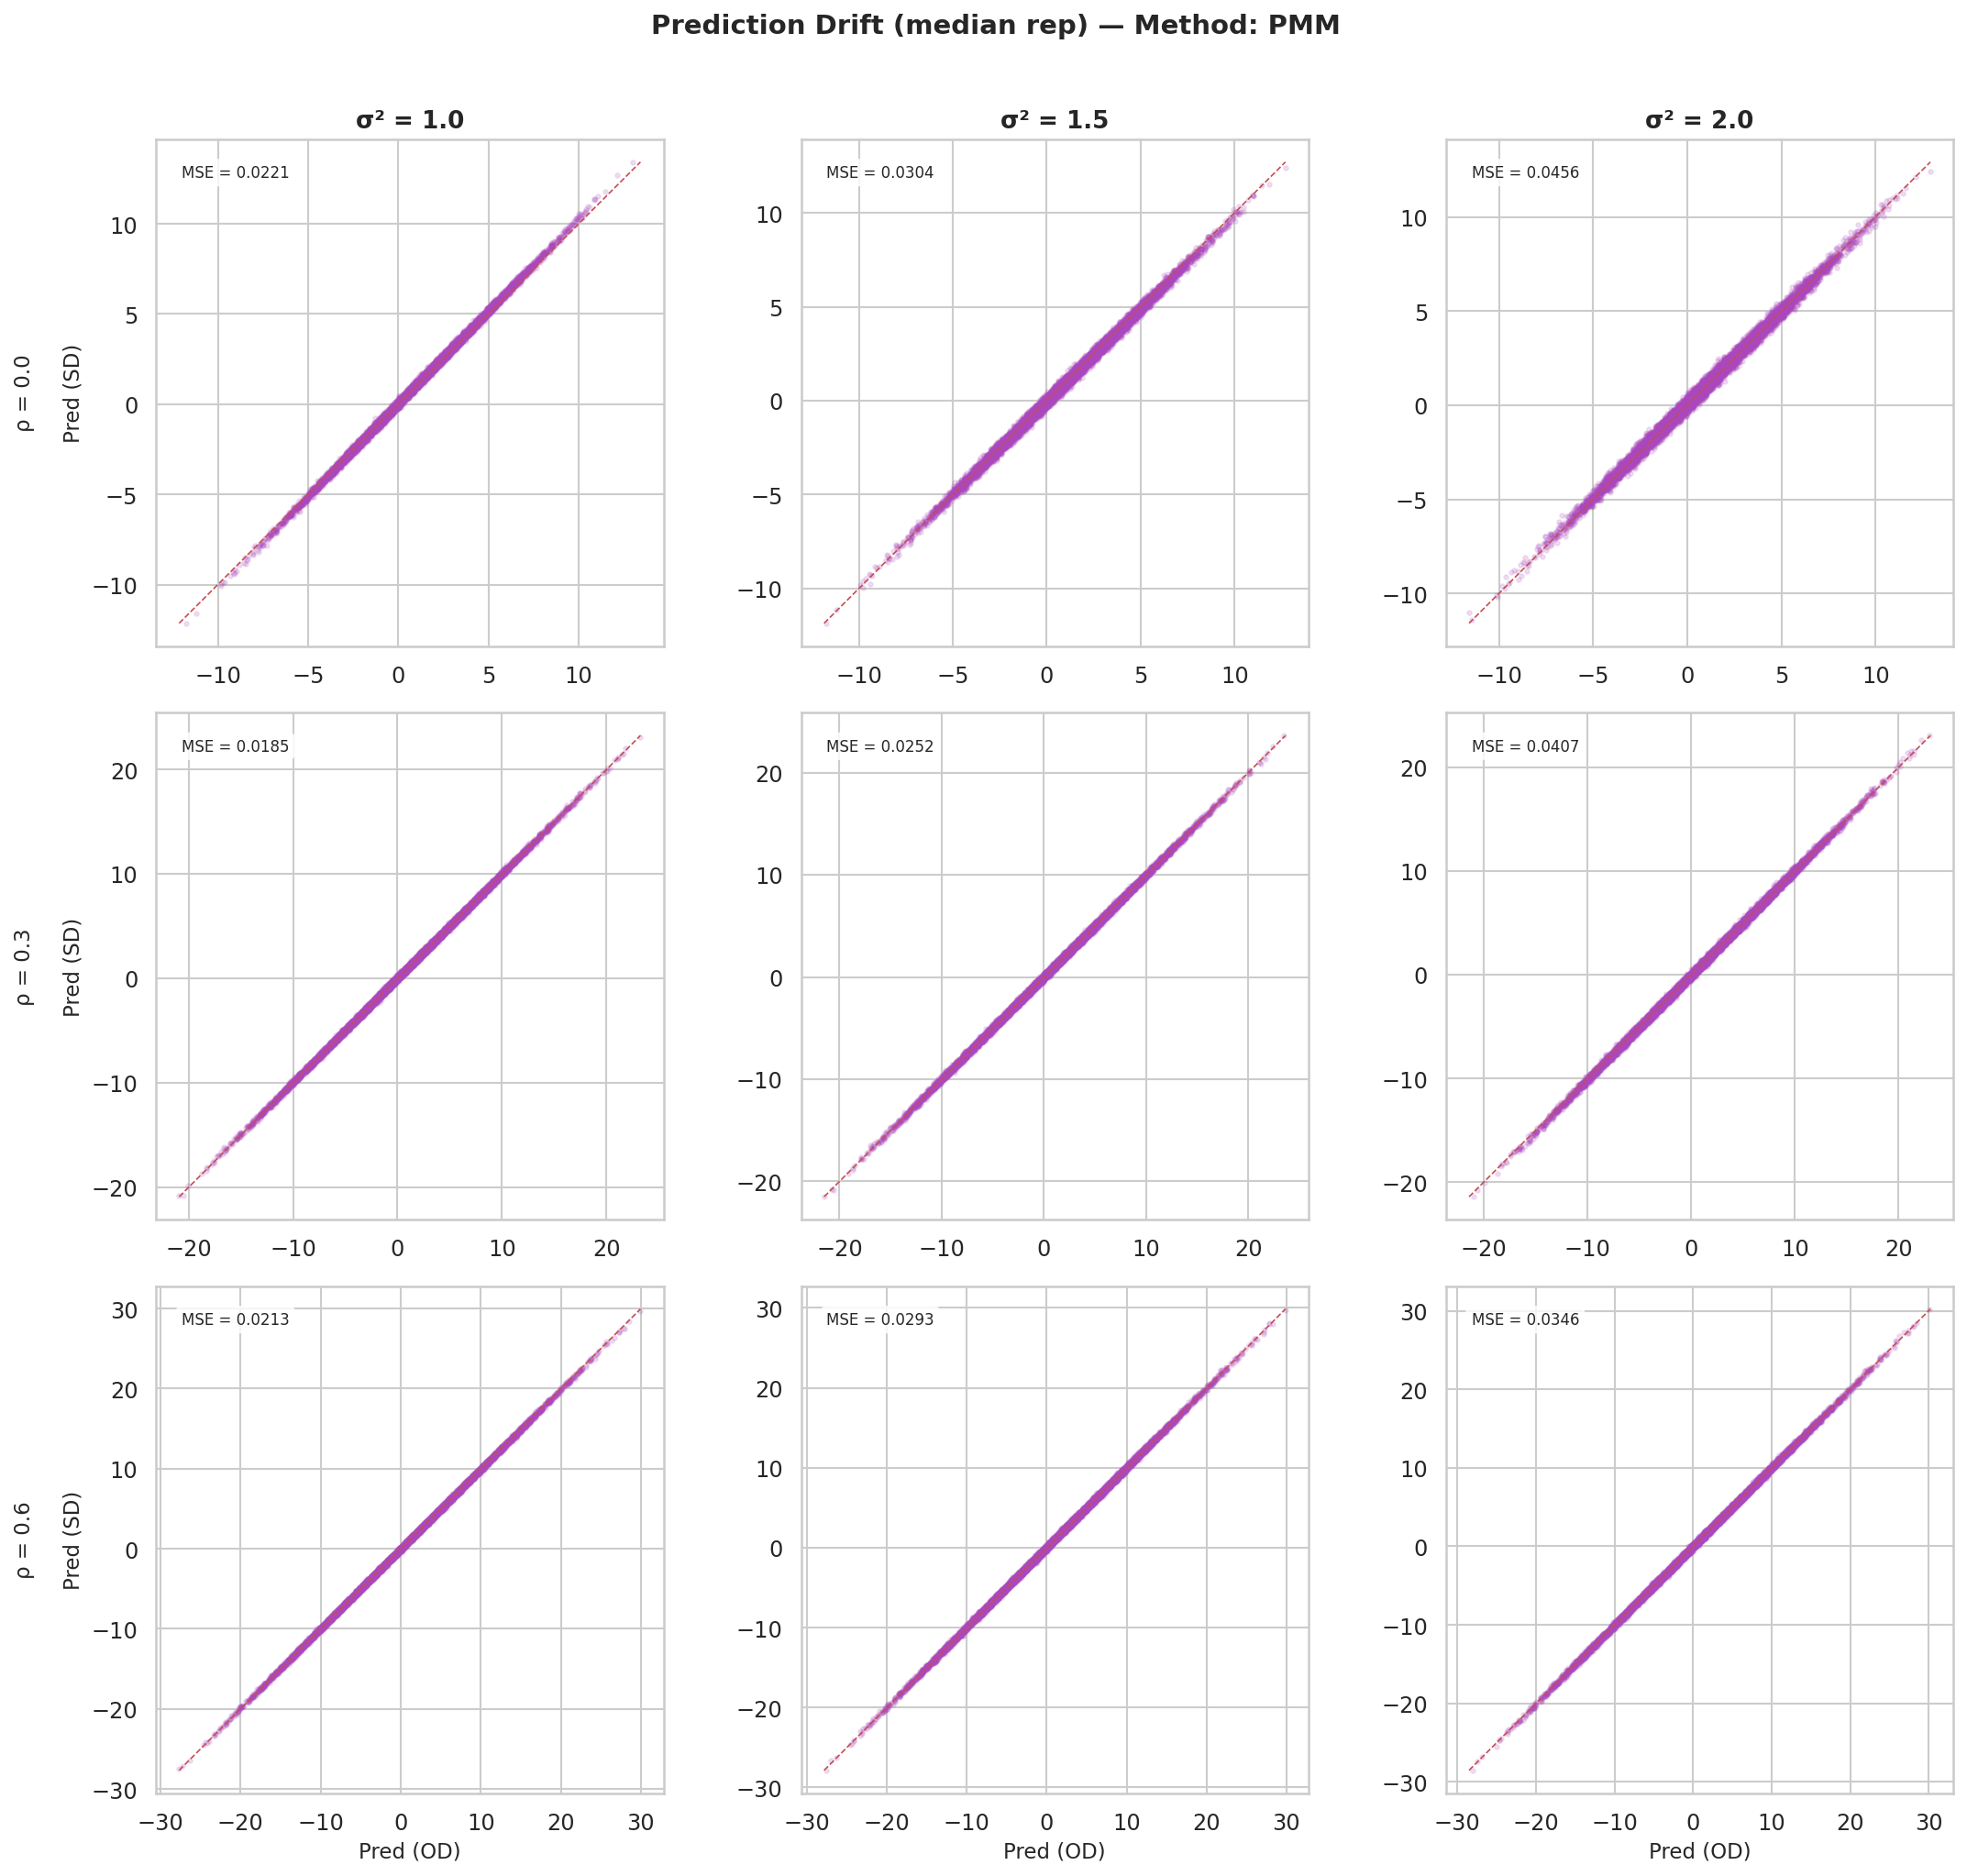

In [21]:
# ── Plot Set B: Prediction Drift Scatter — per method, 3×3 grid ───────────
# Pick the median-Euclidean-distance rep for each cell

for method in methods:
    fig, axes = plt.subplots(
        len(rho_sorted), len(sigma_sorted),
        figsize=(5 * len(sigma_sorted), 4.5 * len(rho_sorted)),
        sharex=False, sharey=False,
    )

    for ri, rho in enumerate(rho_sorted):
        for si, sigma in enumerate(sigma_sorted):
            ax = axes[ri, si]
            sub = metrics_df[
                (metrics_df["method"] == method) &
                (metrics_df["rho"] == rho) &
                (metrics_df["sigma_2"] == sigma)
            ]

            if len(sub) == 0:
                ax.set_visible(False)
                continue

            # Pick median rep
            med = sub["euclidean_dist"].median()
            best_idx = (sub["euclidean_dist"] - med).abs().idxmin()
            best_scenario = sub.loc[best_idx, "scenario"]

            mpath = os.path.join(model_dir, f"models_{best_scenario}.pkl")
            with open(mpath, "rb") as f:
                bundle = pickle.load(f)

            test_data = test_sets[(rho, sigma)]
            X_test = test_data.drop(columns="y")
            pred_od = bundle["lm_od"].predict(X_test)
            pred_sd = bundle["lm_sd"].predict(X_test)

            ax.scatter(pred_od, pred_sd, alpha=0.15, s=5, color="#AB47BC")
            lims = [min(pred_od.min(), pred_sd.min()),
                    max(pred_od.max(), pred_sd.max())]
            ax.plot(lims, lims, "r--", lw=0.8)
            ax.set_aspect("equal")

            mse = sub.loc[best_idx, "prediction_mse"]
            ax.text(0.05, 0.95, f"MSE = {mse:.4f}",
                    transform=ax.transAxes, fontsize=8, va="top",
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

            if ri == 0:
                ax.set_title(f"σ² = {sigma}")
            if si == 0:
                ax.set_ylabel(f"ρ = {rho}\n\nPred (SD)")
            else:
                ax.set_ylabel("")
            if ri == len(rho_sorted) - 1:
                ax.set_xlabel("Pred (OD)")
            else:
                ax.set_xlabel("")

    fig.suptitle(f"Prediction Drift (median rep) — Method: {method.upper()}",
                 fontweight="bold", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(result_dir, f"plot_pred_drift_grid_{method}.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

## Cross-Method Comparison

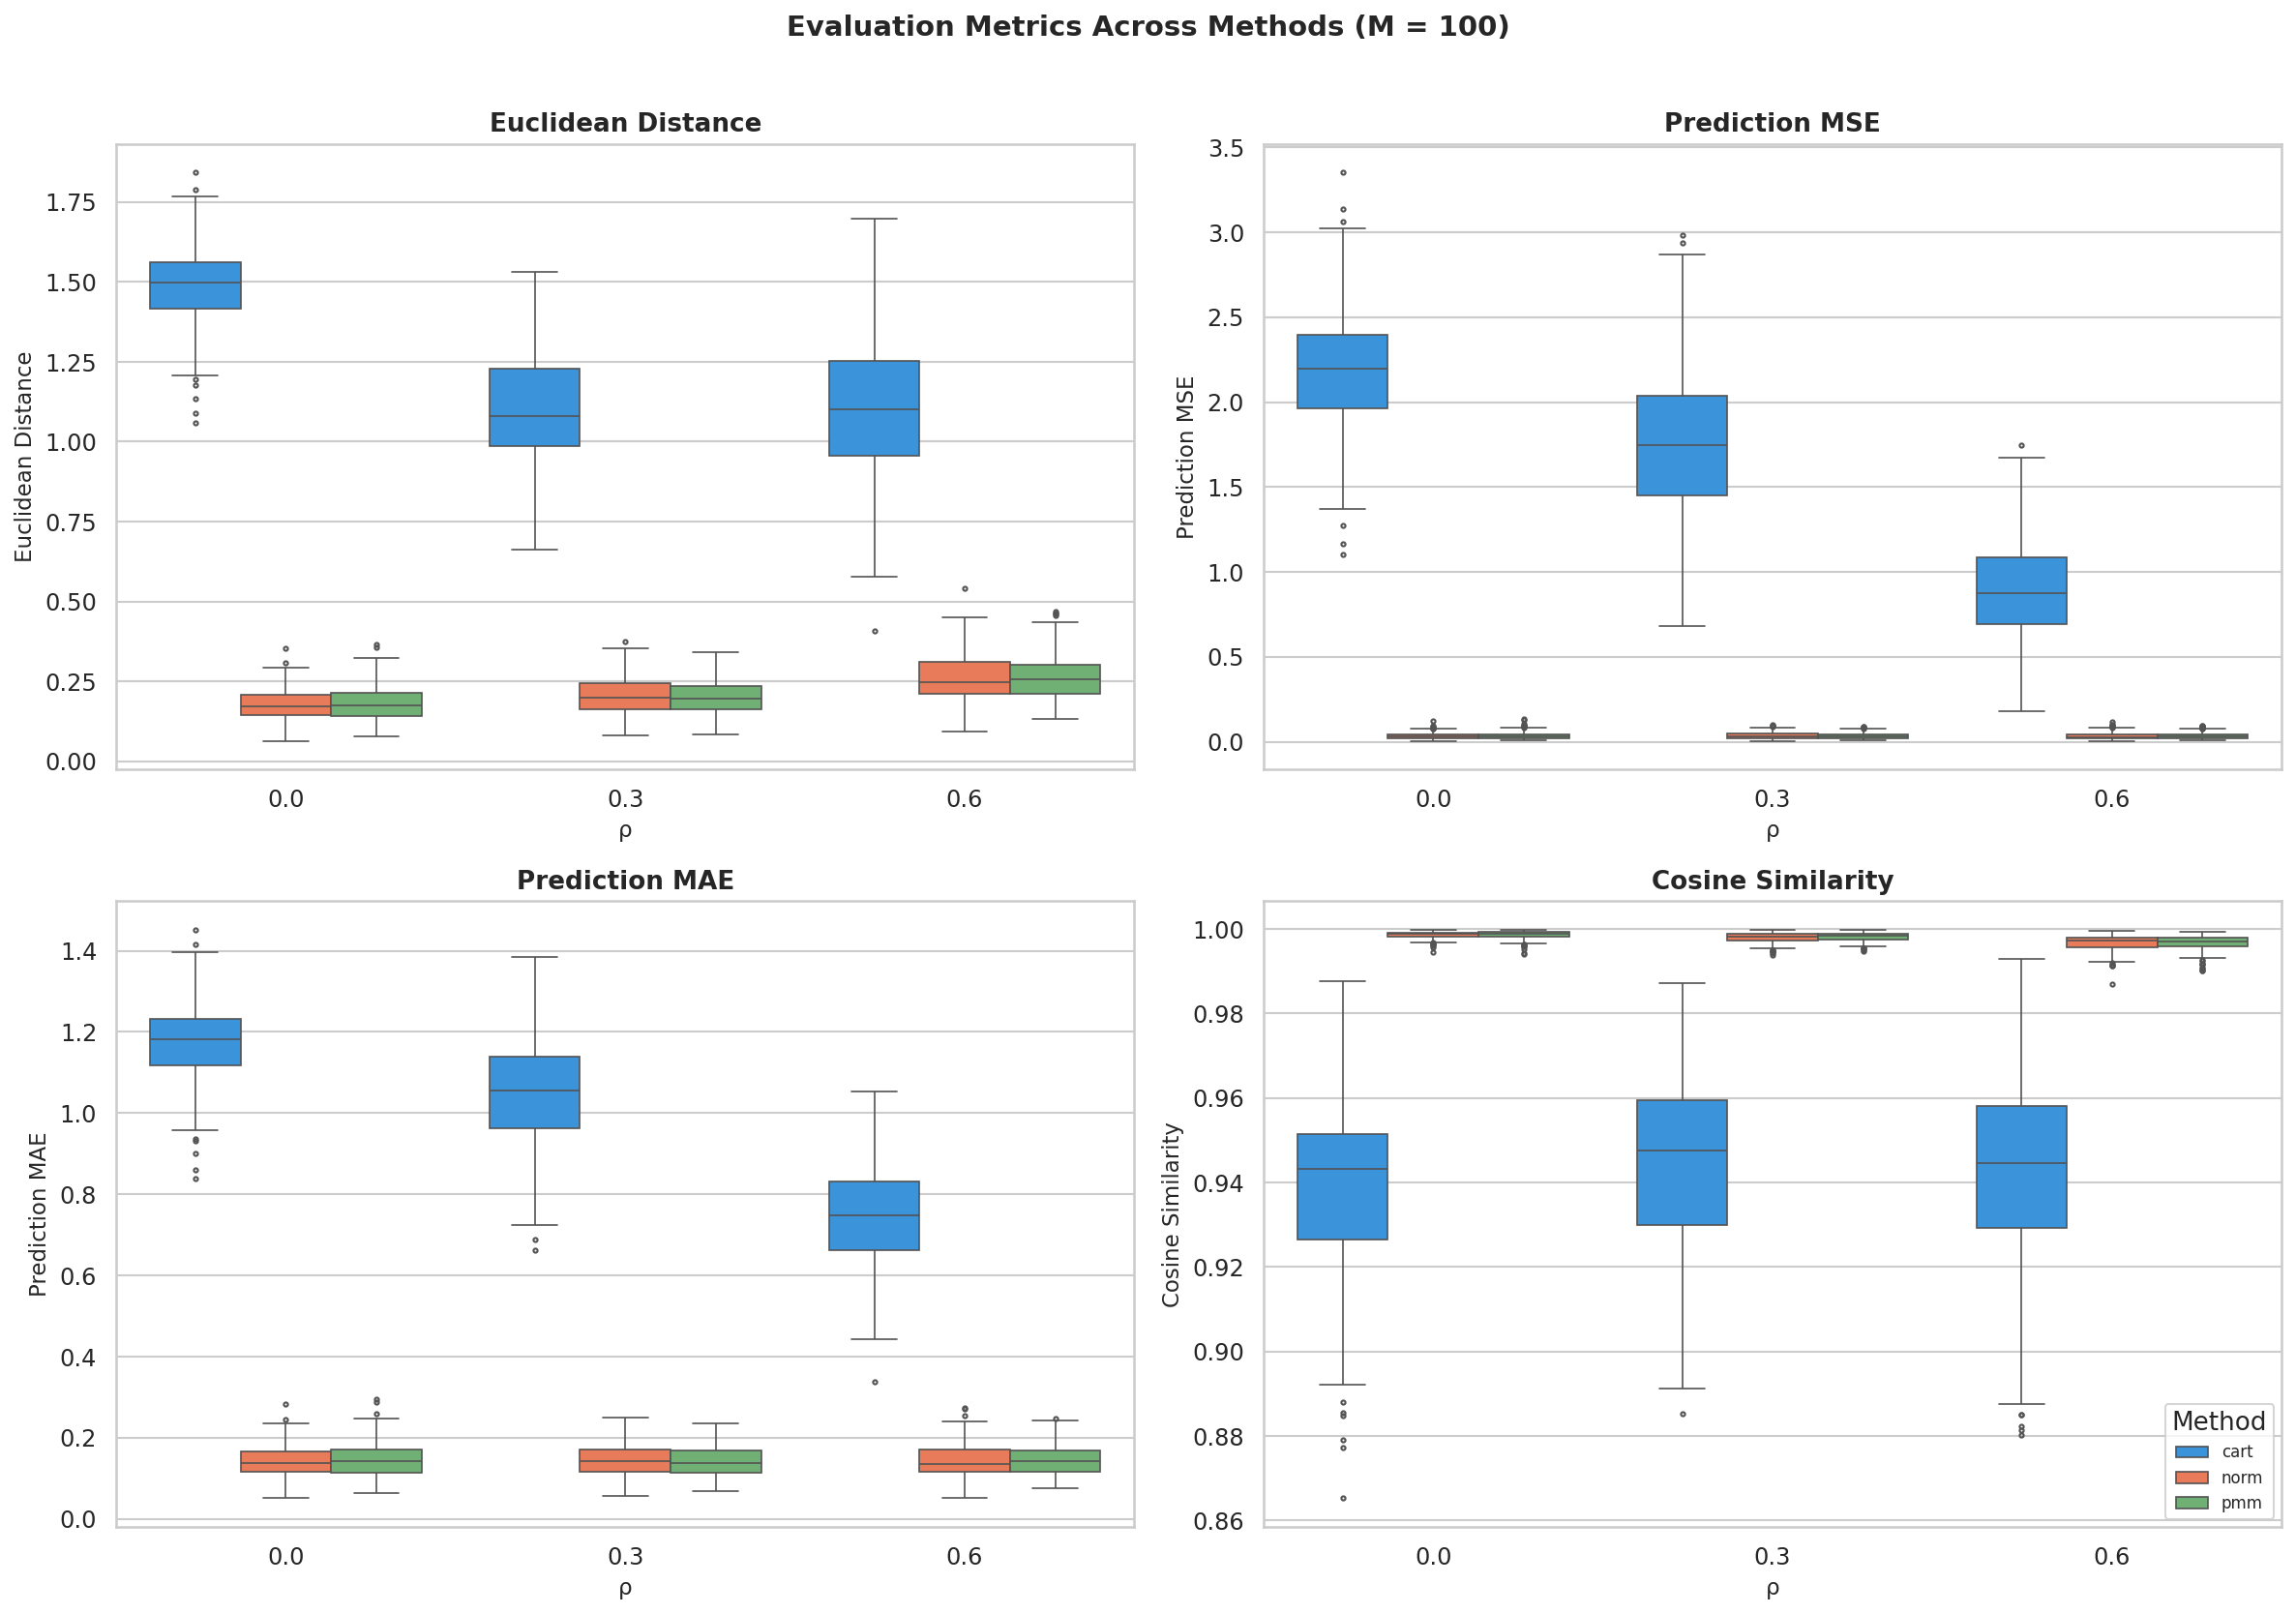

In [22]:
# ── Plot: Key metrics — violin/strip faceted by method ─────────────────────
metric_info = [
    ("euclidean_dist",    "Euclidean Distance"),
    ("prediction_mse",    "Prediction MSE"),
    ("prediction_mae",    "Prediction MAE"),
    ("cosine_similarity", "Cosine Similarity"),
]

method_pal = {"cart": "#2196F3", "norm": "#FF7043", "pmm": "#66BB6A"}

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.ravel()

for ax, (col, title) in zip(axes, metric_info):
    sns.boxplot(
        data=metrics_df, x="rho", y=col, hue="method",
        palette=method_pal, ax=ax, linewidth=0.8, fliersize=2,
    )
    ax.set_title(title)
    ax.set_xlabel("ρ")
    ax.set_ylabel(title)
    if ax != axes[-1]:
        ax.get_legend().remove() if ax.get_legend() else None
    else:
        ax.legend(title="Method", fontsize=8)

plt.suptitle(f"Evaluation Metrics Across Methods (M = {M})",
             fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_metrics_comparison.png"),
            dpi=200, bbox_inches="tight")
plt.show()

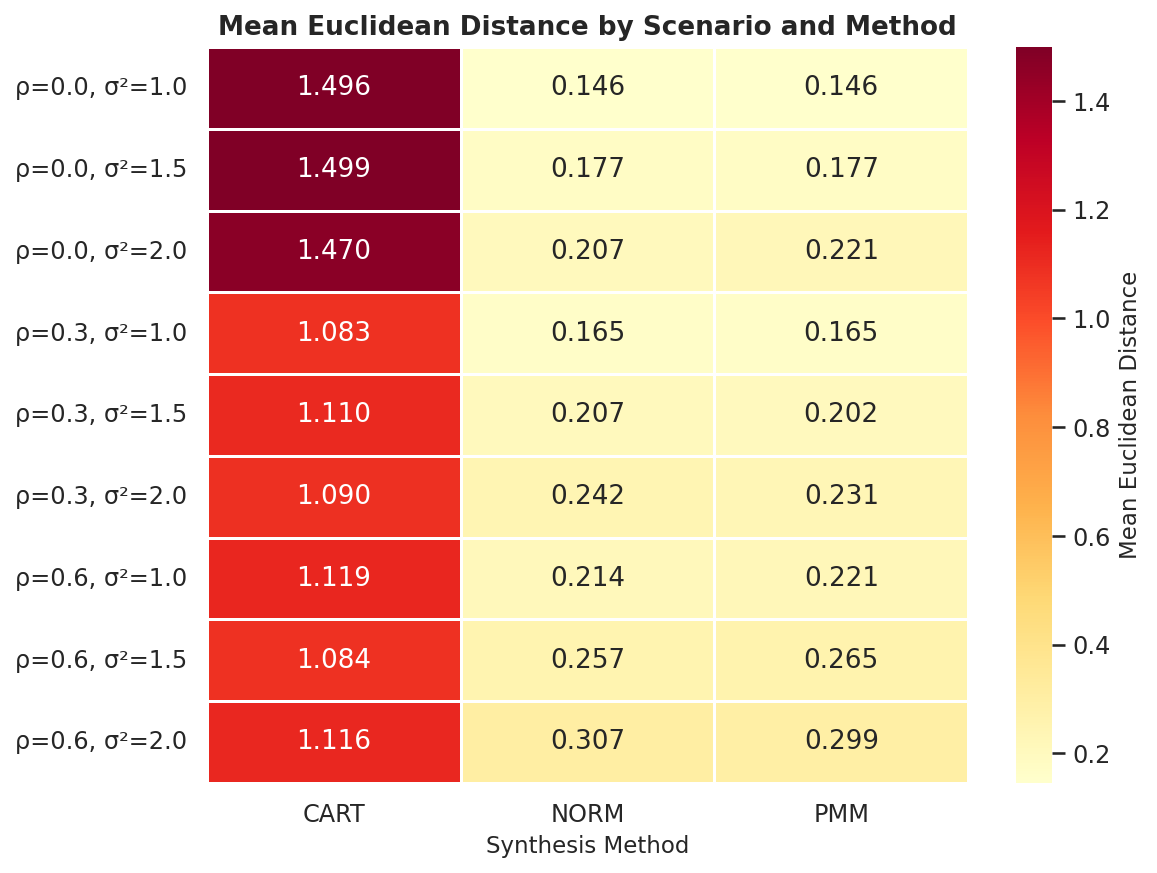

In [23]:
# ── Heatmap: Mean Euclidean Distance — rows = (ρ, σ²), cols = method ──────
mean_eucl = (
    metrics_df
    .groupby(["rho", "sigma_2", "method"])["euclidean_dist"]
    .mean()
    .unstack("method")
)
mean_eucl.index = [f"ρ={r}, σ²={s}" for r, s in mean_eucl.index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    mean_eucl, annot=True, fmt=".3f", cmap="YlOrRd",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Mean Euclidean Distance"},
)
ax.set_title("Mean Euclidean Distance by Scenario and Method")
ax.set_ylabel("")
ax.set_xlabel("Synthesis Method")
ax.set_xticklabels([m.upper() for m in mean_eucl.columns])

plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_eucl_heatmap_by_method.png"),
            dpi=200, bbox_inches="tight")
plt.show()

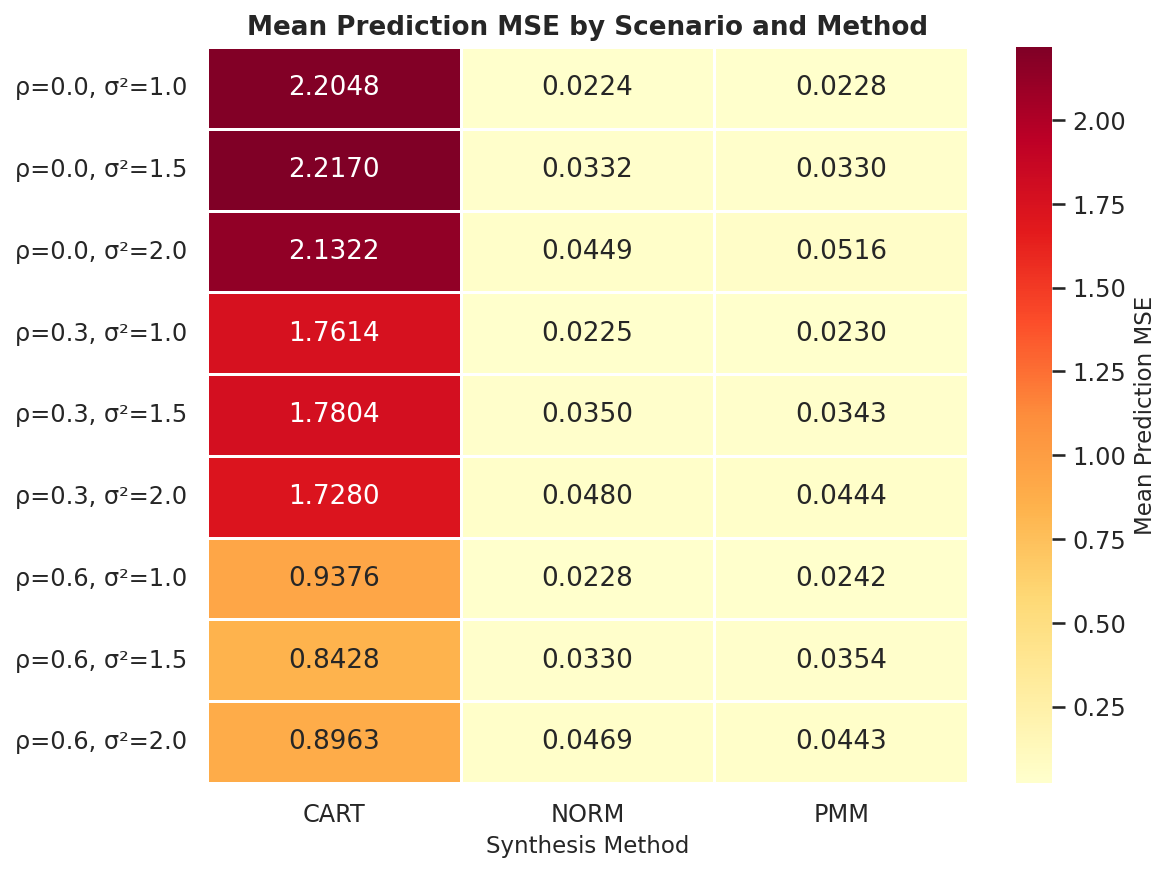

In [24]:
# ── Heatmap: Mean Prediction MSE — same layout ────────────────────────────
mean_mse = (
    metrics_df
    .groupby(["rho", "sigma_2", "method"])["prediction_mse"]
    .mean()
    .unstack("method")
)
mean_mse.index = [f"ρ={r}, σ²={s}" for r, s in mean_mse.index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    mean_mse, annot=True, fmt=".4f", cmap="YlOrRd",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Mean Prediction MSE"},
)
ax.set_title("Mean Prediction MSE by Scenario and Method")
ax.set_ylabel("")
ax.set_xlabel("Synthesis Method")
ax.set_xticklabels([m.upper() for m in mean_mse.columns])

plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_mse_heatmap_by_method.png"),
            dpi=200, bbox_inches="tight")
plt.show()

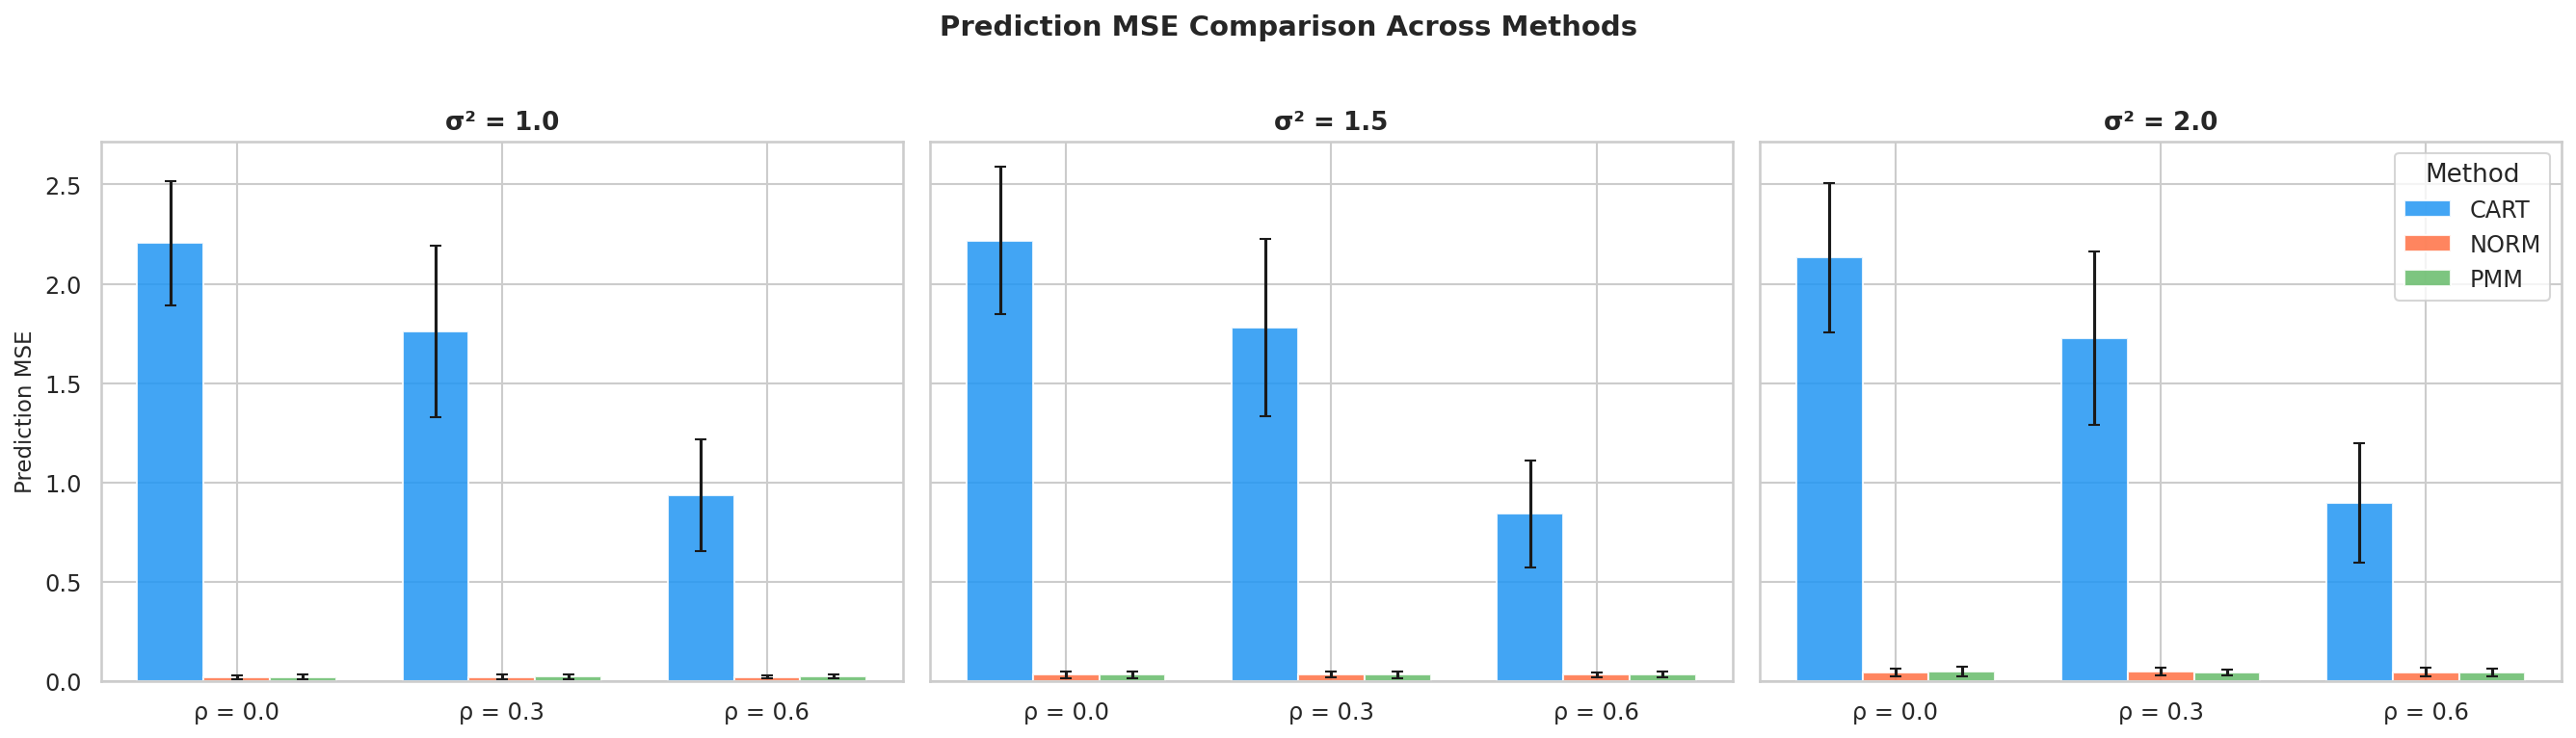

In [25]:
# ── Summary bar chart: Mean MSE with error bars — grouped by method ───────
fig, axes = plt.subplots(1, len(sigma_sorted),
                         figsize=(6 * len(sigma_sorted), 5), sharey=True)
if len(sigma_sorted) == 1:
    axes = [axes]

for ax, sigma in zip(axes, sigma_sorted):
    sub = metrics_df[metrics_df["sigma_2"] == sigma]
    x = np.arange(len(rho_sorted))
    width = 0.25

    for mi, method in enumerate(methods):
        msub = sub[sub["method"] == method].groupby("rho")["prediction_mse"]
        means = msub.mean().reindex(rho_sorted)
        stds  = msub.std().reindex(rho_sorted)
        ax.bar(
            x + mi * width, means.values, width,
            yerr=stds.values, label=method.upper(),
            color=method_pal[method], edgecolor="white", capsize=3, alpha=0.85,
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels([f"ρ = {r}" for r in rho_sorted])
    ax.set_title(f"σ² = {sigma}")
    ax.set_ylabel("Prediction MSE" if ax == axes[0] else "")
    if ax == axes[-1]:
        ax.legend(title="Method")

plt.suptitle("Prediction MSE Comparison Across Methods",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_mse_comparison.png"),
            dpi=200, bbox_inches="tight")
plt.show()

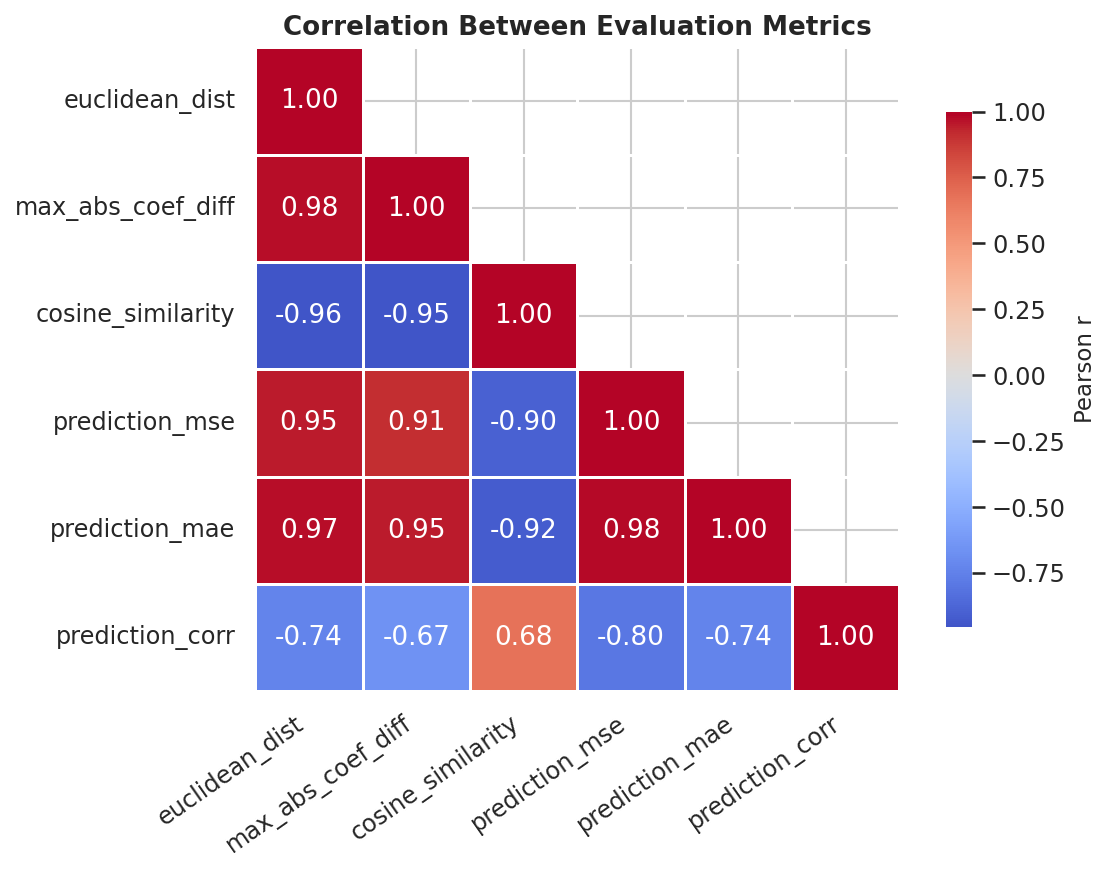


[DONE] Evaluation complete. All metrics and plots saved to ../results/


In [26]:
# ── Metric correlation heatmap (all methods pooled) ────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
corr = metrics_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title("Correlation Between Evaluation Metrics")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")

plt.tight_layout()
plt.savefig(os.path.join(result_dir, "plot_metric_correlation.png"),
            dpi=200, bbox_inches="tight")
plt.show()

print("\n[DONE] Evaluation complete. All metrics and plots saved to ../results/")